In [23]:
import os
import pickle
import json
import utils
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from data import get_data, preprocess_data
from config import config

with open("model/gfr_dataset.json", "r") as f:
    json_dataset = json.load(f)

dataset = utils.df_from_json(json_dataset)

cell_ids = set()
for k in dataset.keys():
    cell_ids = cell_ids.union(set(dataset[k]["cell_id"].to_list()))
cell_ids = list(cell_ids)

In [ ]:
with open("cell_ids.csv", "w") as f:
    f.write(",".join(map(str, cell_ids)))

In [24]:
class PolynomialActivation(torch.nn.Module):
    def __init__(self, degree, max_current, max_firing_rate, bin_size):
        super().__init__()
        self.degree = degree
        self.max_current = torch.nn.Parameter(torch.tensor(max_current).reshape(1), requires_grad=False)
        self.max_firing_rate = torch.nn.Parameter(torch.tensor(max_firing_rate).reshape(1), requires_grad=False)
        self.bin_size = bin_size
        self.p = torch.nn.Parameter(torch.tensor([d for d in range(degree+1)]), requires_grad=False)
        self.poly_coeff = torch.nn.Parameter(torch.randn(1, self.degree + 1))
        self.b = torch.nn.Parameter(torch.tensor([0.0]))  # input shift

    def forward(self, z):
        # z input assumed raw current
        x = (z - self.b) / self.max_current
        poly = torch.einsum("ijk,jk->ij",
                            x.unsqueeze(dim=2).pow(self.p.reshape(1, 1, -1)),
                            self.poly_coeff ** 2)
        tan = self.max_firing_rate * torch.tanh(poly)
        return F.relu(tan).to(torch.float32)

    def get_params(self):
        return {
            "type": "polynomial",
            "degree": self.degree,
            "max_current": self.max_current.item(),
            "max_firing_rate": self.max_firing_rate.item(),
            "poly_coeff": self.poly_coeff.detach().cpu().tolist(),
            "b": self.b.detach().cpu().tolist(),
            "bin_size": self.bin_size
        }

    @classmethod
    def from_params(cls, params):
        g = cls(params["degree"], params["max_current"], params["max_firing_rate"], params["bin_size"])
        g.poly_coeff = torch.nn.Parameter(torch.tensor(params["poly_coeff"]))
        g.b = torch.nn.Parameter(torch.tensor(params["b"]))
        return g

class ReLUActivation(torch.nn.Module):
    def __init__(self, bin_size, max_current):
        super().__init__()
        self.a = torch.nn.Parameter(torch.randn(1))  # slope
        self.b = torch.nn.Parameter(torch.zeros(1))  # input shift
        self.c = torch.nn.Parameter(torch.zeros(1))  # output bias
        self.bin_size = bin_size
        self.max_current = torch.nn.Parameter(torch.tensor(max_current).reshape(1), requires_grad=False)

    def forward(self, z):
        # linear form: y = a*( (z - b)/max_current ) + c, then ReLU
        x = (z - self.b) / self.max_current
        y = self.a * x + self.c
        return F.relu(y)

    def get_params(self):
        return {
            "type": "relu",
            "a": self.a.detach().item(),
            "b": self.b.detach().item(),
            "c": self.c.detach().item(),
            "max_current": self.max_current.item(),
            "bin_size": self.bin_size
        }

    @classmethod
    def from_params(cls, params):
        g = cls(params["bin_size"], params["max_current"])
        g.a = torch.nn.Parameter(torch.tensor(params["a"]))
        g.b = torch.nn.Parameter(torch.tensor(params["b"]))
        g.c = torch.nn.Parameter(torch.tensor(params["c"]))
        return g

class SigmoidActivation(torch.nn.Module):
    def __init__(self, bin_size, max_firing_rate, max_current):
        super().__init__()
        self.a = torch.nn.Parameter(torch.randn(1))  # slope
        self.b = torch.nn.Parameter(torch.zeros(1))  # input shift
        self.c = torch.nn.Parameter(torch.zeros(1))  # output bias
        self.bin_size = bin_size
        self.max_current = torch.nn.Parameter(torch.tensor(max_current).reshape(1), requires_grad=False)
        self.max_firing_rate = torch.nn.Parameter(torch.tensor(max_firing_rate).reshape(1), requires_grad=False)

    def forward(self, z):
        # y = max_firing_rate * sigmoid(a*((z-b)/max_current) + c)
        x = (z - self.b) / self.max_current
        s = self.a * x + self.c
        return self.max_firing_rate * torch.sigmoid(s)

    def get_params(self):
        return {
            "type": "sigmoid",
            "a": self.a.detach().item(),
            "b": self.b.detach().item(),
            "c": self.c.detach().item(),  # post-normalization bias
            "max_current": self.max_current.item(),
            "max_firing_rate": self.max_firing_rate.item(),
            "bin_size": self.bin_size
        }

    @classmethod
    def from_params(cls, params):
        g = cls(params["bin_size"], params["max_firing_rate"], params["max_current"])
        g.a = torch.nn.Parameter(torch.tensor(params["a"]))
        g.b = torch.nn.Parameter(torch.tensor(params["b"]))
        g.c = torch.nn.Parameter(torch.tensor(params["c"]))
        return g

class SoftplusActivation(torch.nn.Module):
    def __init__(self, bin_size, max_current):
        super().__init__()
        self.a = torch.nn.Parameter(torch.ones(1))  # slope
        self.b = torch.nn.Parameter(torch.zeros(1))  # input shift
        self.c = torch.nn.Parameter(torch.zeros(1))  # output bias
        self.bin_size = bin_size
        self.max_current = torch.nn.Parameter(torch.tensor(max_current).reshape(1), requires_grad=False)

    def forward(self, z):
        # y = softplus(a*((z-b)/max_current) + c)
        x = (z - self.b) / self.max_current
        s = self.a * x + self.c
        return F.softplus(s)

    def get_params(self):
        return {
            "type": "softplus",
            "a": self.a.detach().item(),
            "b": self.b.detach().item(),
            "c": self.c.detach().item(),
            "max_current": self.max_current.item(),
            "bin_size": self.bin_size
        }

    @classmethod
    def from_params(cls, params):
        g = cls(params["bin_size"], params["max_current"])
        g.a = torch.nn.Parameter(torch.tensor(params["a"]))
        g.b = torch.nn.Parameter(torch.tensor(params["b"]))
        g.c = torch.nn.Parameter(torch.tensor(params["c"]))
        return g

# -----------------------------------------------------------------------------
# Utility: Initialize activation from data
# -----------------------------------------------------------------------------
def activation_from_data(
    cls,
    max_current,
    max_firing_rate,
    bin_size,
    Is,
    fs,
    degree=None
):
    """
    Initialize activation g of class `cls` based on (Is, fs) data.

    PolynomialActivation -> polynomial fit with degree.
    ReLU/Sigmoid/Softplus -> affine a*z + c, with two biases (input shift b, output bias c).
    Sigmoid scaled by max_firing_rate.
    """
    # sort data by input current
    xs, ys = map(list, zip(*sorted(zip(Is.cpu(), fs.cpu()), key=lambda x: x[0])))
    # find max firing
    i_max = int(torch.argmax(torch.tensor(ys)))
    x2, y2 = xs[i_max], ys[i_max]
    # threshold at first >0.01
    x1, y1 = xs[0], ys[0]
    for i in range(len(ys)):
        if ys[i] > 0.01:
            x1, y1 = (xs[i-1], ys[i-1]) if i > 0 else (xs[i], ys[i])
            break
    slope = float((y2 - y1) / (x2 - x1 + 1e-8))

    if cls is PolynomialActivation:
        if degree is None:
            raise ValueError("PolynomialActivation requires degree")
        g = cls(degree, max_current, max_firing_rate, bin_size)
        g.b = torch.nn.Parameter(torch.tensor([float(x1)]))
        coeffs = torch.randn(degree + 1) * 1e-1
        coeffs[1] = abs(slope * max_current)
        g.poly_coeff = torch.nn.Parameter(coeffs.reshape(1, -1).float())
        return g

    if cls is ReLUActivation:
        g = cls(bin_size, max_current)
        a = abs(slope) * max_current
        b = a * float(x1)
        g.a = torch.nn.Parameter(torch.tensor([a]))
        g.b = torch.nn.Parameter(torch.tensor([b]))
        # c remains default
        return g

    if cls is SigmoidActivation:
        g = cls(bin_size, max_firing_rate, max_current)
        a = abs(slope) * max_current * 4.0 / float(g.max_firing_rate)
        b = a * float(x1)
        g.a = torch.nn.Parameter(torch.tensor([a]))
        g.b = torch.nn.Parameter(torch.tensor([b]))
        # c remains default
        return g

    if cls is SoftplusActivation:
        g = cls(bin_size, max_current)
        a = abs(slope) * max_current
        b = a * float(x1)
        g.a = torch.nn.Parameter(torch.tensor([a]))
        g.b = torch.nn.Parameter(torch.tensor([b]))
        # c remains default
        return g

    raise ValueError(f"Unsupported activation class: {cls}")


# -----------------------------------------------------------------------------
# Get or initialize activations with data-driven init
# -----------------------------------------------------------------------------
def get_activations(
    act_type,
    Is_train,
    fs_train,
    bin_size,
    epochs=1000,
    device=None,
    g=None,
    degree=None,
    max_firing_rate=None,
    Is_test=None,
    fs_test=None
):
    if g is None:
        max_current = float(torch.max(torch.abs(
            torch.cat((Is_train, Is_test) if Is_test is not None else Is_train)
        )))
        g = make_activation(
            act_type,
            bin_size,
            max_current,
            max_firing_rate,
            Is_train,
            fs_train,
            degree
        )
    g = g.to(device)
    criterion = torch.nn.PoissonNLLLoss(log_input=False)
    optimizer = torch.optim.Adam(g.parameters(), lr=0.05)
    train_losses, test_losses = fit_activation(
        g, criterion, optimizer,
        Is_train, fs_train,
        Is_test, fs_test,
        epochs
    )
    return g, train_losses, test_losses

# -----------------------------------------------------------------------------
# Factory: make_activation now uses data-driven initializer
# -----------------------------------------------------------------------------
def make_activation(
    act_type: str,
    bin_size: float,
    max_current: float,
    max_firing_rate: float,
    Is,
    fs,
    degree=None
):
    """
    Factory that initializes an activation of type act_type based on sample data (Is, fs).
    Uses activation_from_data for parameter initialization.
    """
    if max_current is None:
        raise ValueError("make_activation requires max_current")
    if act_type == 'polynomial':
        if degree is None or max_firing_rate is None:
            raise ValueError("PolynomialActivation requires degree and max_firing_rate")
        return activation_from_data(PolynomialActivation, max_current, max_firing_rate, bin_size, Is, fs, degree)
    elif act_type == 'relu':
        return activation_from_data(ReLUActivation, max_current, max_firing_rate, bin_size, Is, fs)
    elif act_type == 'sigmoid':
        if max_firing_rate is None:
            raise ValueError("SigmoidActivation requires max_firing_rate")
        return activation_from_data(SigmoidActivation, max_current, max_firing_rate, bin_size, Is, fs)
    elif act_type == 'softplus':
        return activation_from_data(SoftplusActivation, max_current, max_firing_rate, bin_size, Is, fs)
    else:
        raise ValueError(f"Unknown activation type: {act_type}")

# -----------------------------------------------------------------------------
# Fitting routines (with train/test split)
# -----------------------------------------------------------------------------
def fit_activation(
    actv,
    criterion,
    optimizer,
    Is_train,
    fs_train,
    Is_test=None,
    fs_test=None,
    epochs=1000
):
    train_losses = []
    test_losses = []
    for _ in range(epochs):
        # training step
        total_train = 0
        for current, fr in zip(Is_train, fs_train):
            current = current.reshape(1,1)
            pred = actv(current)
            loss = criterion(pred * actv.bin_size, fr.reshape(1,1) * actv.bin_size)
            total_train += loss
        optimizer.zero_grad()
        total_train.backward()
        optimizer.step()
        train_losses.append(total_train.item() / len(Is_train))
        # evaluation on test set
        if Is_test is not None and fs_test is not None:
            with torch.no_grad():
                total_test = 0
                for current, fr in zip(Is_test, fs_test):
                    current = current.reshape(1,1)
                    pred = actv(current)
                    loss = criterion(pred * actv.bin_size, fr.reshape(1,1) * actv.bin_size)
                    total_test += loss
                test_losses.append(total_test.item() / len(Is_test))
    return train_losses, test_losses

# -----------------------------------------------------------------------------
# Full model fitting including activation train/test split
# -----------------------------------------------------------------------------
def fit_model(
    cell_id,
    activation_bin_size,
    activation_type,
    max_firing_rate=None,
    degree=None,
    device=None,
    g=None
):
    data = get_data(cell_id)
    Is_np, fs_np = preprocess_data(data, activation_bin_size)
    Is = torch.tensor(Is_np).to(device)
    fs = torch.tensor(fs_np).to(device)

    # split into train/test
    n = len(Is)
    gen = torch.Generator().manual_seed(42)
    idx = torch.randperm(n, generator=gen)
    train_size = int(0.8 * n)
    train_idx, test_idx = idx[:train_size], idx[train_size:]
    Is_train, fs_train = Is[train_idx], fs[train_idx]
    Is_test, fs_test = Is[test_idx], fs[test_idx]

    # fit activation
    g, train_losses, test_losses = get_activations(
        activation_type,
        Is_train,
        fs_train,
        activation_bin_size,
        epochs=1000,
        device=device,
        g=g,
        degree=degree,
        max_firing_rate=max_firing_rate,
        Is_test=Is_test,
        fs_test=fs_test
    )
    activation_params = g.get_params()

    # return activations and their losses
    return activation_params, train_losses, test_losses

def summarize_losses(df):
    """
    Given a DataFrame with columns
      ['cell_id', 'activation_bin_size', 'activation_type', 'train_loss', 'test_loss'],
    returns a new DataFrame with the mean train_loss and test_loss grouped by
    activation_type and activation_bin_size.
    """
    # group and average
    summary = (
        df
        .groupby(['activation_type', 'activation_bin_size'])[['train_loss','test_loss']]
        .mean()
        .reset_index()
    )
    return summary

def summarize_losses2(df):
    """
    Given a DataFrame with columns
      ['cell_id', 'activation_bin_size', 'activation_type', 'train_loss', 'test_loss'],
    returns a new DataFrame with the mean train_loss and test_loss grouped by
    activation_type and activation_bin_size, but only including cell_ids common to
    all activation_types within each activation_bin_size.
    """
    import pandas as pd

    results = []
    # For each bin size, only keep cell_ids present in every activation_type
    for bin_size, group in df.groupby('activation_bin_size'):
        types = group['activation_type'].unique()
        # build sets of cell_ids per type
        id_sets = [set(group[group['activation_type'] == t]['cell_id']) for t in types]
        common_ids = set.intersection(*id_sets) if id_sets else set()
        # filter down to those cell_ids
        filtered = group[group['cell_id'].isin(common_ids)]
        # compute mean losses per activation_type for this bin
        summary_bin = (
            filtered
            .groupby(['activation_type', 'activation_bin_size'])[['train_loss', 'test_loss']]
            .mean()
            .reset_index()
        )
        results.append(summary_bin)

    # concatenate all bins (or return empty frame if none)
    if results:
        summary = pd.concat(results, ignore_index=True)
    else:
        summary = pd.DataFrame(columns=['activation_type', 'activation_bin_size', 'train_loss', 'test_loss'])
    return summary


In [26]:
# USER‑SET: list of cell IDs and your bin size
# cell_ids = [313860745]
activation_bin_sizes = [20, 100]
actv_types = ['polynomial', 'relu', 'sigmoid', 'softplus']
# cell_ids = cell_ids[:10]

rows = []
for idx, cell_id in enumerate(tqdm(cell_ids), start=1):
    path = config["data_path"] + f"processed_I_and_firing_rate_{cell_id}.pickle"

    if not os.path.exists(path):
        print(f"Skipping cell {cell_id}: data file does not exist.")
    else:
        with open(f"{config['mfr_path']}{cell_id}.pickle", "rb") as f:
            max_firing_rate = pickle.load(f)

        for act_type in actv_types:
            for activation_bin_size in activation_bin_sizes:
                out_path = f"data/activation_function/{cell_id}_{activation_bin_size}_{act_type}.pickle"
                if os.path.exists(out_path):
                    print(f"Skipping {cell_id}, {activation_bin_size}, {act_type}: already fitted.")
                    with open(out_path, "rb") as f:
                        data = pickle.load(f)
                else:
                    activation_params, train_losses, test_losses = fit_model(
                        cell_id,
                        activation_bin_size,
                        act_type,
                        max_firing_rate,
                        degree=3
                    )
                    data = {
                        'activation_bin_size': activation_bin_size,
                        'activation_type': act_type,
                        'train_loss': train_losses[-1],
                        'test_loss': test_losses[-1],
                        'activation_params': activation_params
                    }
                    with open(out_path, "wb") as f:
                        pickle.dump(data, f)

                rows.append({
                    'cell_id': cell_id,
                    'activation_bin_size': data['activation_bin_size'],
                    'activation_type': data['activation_type'],
                    'train_loss': data['train_loss'],
                    'test_loss': data['test_loss'],
                    'activation_params': data['activation_params']
                })

    # every 10 cells, print a summary
    if idx % 10 == 0:
        df_temp = pd.DataFrame(rows)
        summary = summarize_losses(df_temp)
        print(f"\n=== Summary after {idx} cells ===")
        print(summary)


# build & inspect
df = pd.DataFrame(rows)

# # save dataframe as pickle
with open("model/activation_fits.pickle", "wb") as f:
    pickle.dump(df, f)

  0%|          | 0/1796 [00:00<?, ?it/s]

Skipping 566517779, 20, polynomial: already fitted.
Skipping 566517779, 100, polynomial: already fitted.
Skipping 566517779, 20, relu: already fitted.
Skipping 566517779, 100, relu: already fitted.
Skipping 566517779, 20, sigmoid: already fitted.
Skipping 566517779, 100, sigmoid: already fitted.
Skipping 566517779, 20, softplus: already fitted.
Skipping 566517779, 100, softplus: already fitted.
Skipping 486875162, 20, polynomial: already fitted.
Skipping 486875162, 100, polynomial: already fitted.
Skipping 486875162, 20, relu: already fitted.
Skipping 486875162, 100, relu: already fitted.
Skipping 486875162, 20, sigmoid: already fitted.
Skipping 486875162, 100, sigmoid: already fitted.
Skipping 486875162, 20, softplus: already fitted.
Skipping 486875162, 100, softplus: already fitted.
Skipping 562651165, 20, polynomial: already fitted.
Skipping 562651165, 100, polynomial: already fitted.
Skipping 562651165, 20, relu: already fitted.
Skipping 562651165, 100, relu: already fitted.
Skippi

  1%|          | 20/1796 [02:12<5:10:48, 10.50s/it]


=== Summary after 20 cells ===
  activation_type  activation_bin_size  train_loss  test_loss
0      polynomial                   20    0.097629   0.101517
1      polynomial                  100   -0.395129  -0.606487
2            relu                   20    0.806031   0.854228
3            relu                  100   10.076585  11.091348
4         sigmoid                   20    0.982070   0.903008
5         sigmoid                  100   -0.209304  -0.399507
6        softplus                   20    0.162121   0.175286
7        softplus                  100   -0.141984  -0.309337


  2%|▏         | 30/1796 [03:57<5:50:18, 11.90s/it]

...

 99%|█████████▉| 1780/1796 [5:34:34<03:02, 11.41s/it]


=== Summary after 1780 cells ===
  activation_type  activation_bin_size  train_loss  test_loss
0      polynomial                   20    0.131744   0.276398
1      polynomial                  100   -0.694468  -0.340132
2            relu                   20    0.706069   0.880843
3            relu                  100   11.449874  11.778723
4         sigmoid                   20    1.198670   1.067932
5         sigmoid                  100    0.180058   0.347528
6        softplus                   20    0.222994   0.275445
7        softplus                  100   -0.371121  -0.176887


100%|█████████▉| 1790/1796 [5:36:36<01:02, 10.35s/it]


=== Summary after 1790 cells ===
  activation_type  activation_bin_size  train_loss  test_loss
0      polynomial                   20    0.131686   0.275580
1      polynomial                  100   -0.694389  -0.339006
2            relu                   20    0.707193   0.881011
3            relu                  100   11.455191  11.771356
4         sigmoid                   20    1.197496   1.064072
5         sigmoid                  100    0.176185   0.345412
6        softplus                   20    0.222802   0.275055
7        softplus                  100   -0.371211  -0.174849


100%|██████████| 1796/1796 [5:37:40<00:00, 11.28s/it]


In [27]:
summary_df = summarize_losses(df)
print(summary_df)

  activation_type  activation_bin_size  train_loss  test_loss
0      polynomial                   20    0.131423   0.275182
1      polynomial                  100   -0.692052  -0.337580
2            relu                   20    0.706501   0.884345
3            relu                  100   11.455693  11.776961
4         sigmoid                   20    1.197201   1.068734
5         sigmoid                  100    0.175941   0.344527
6        softplus                   20    0.222400   0.274723
7        softplus                  100   -0.368993  -0.173094


In [28]:
# drop nan rows in df
df_no_nan = df.dropna(subset=['train_loss', 'test_loss'])
summary_no_nan = summarize_losses(df_no_nan)
print(summary_no_nan)

  activation_type  activation_bin_size  train_loss  test_loss
0      polynomial                   20    0.131423   0.275182
1      polynomial                  100   -0.692052  -0.337580
2            relu                   20    0.706501   0.884345
3            relu                  100   11.455693  11.776961
4         sigmoid                   20    1.197201   1.068734
5         sigmoid                  100    0.175941   0.344527
6        softplus                   20    0.222400   0.274723
7        softplus                  100   -0.368993  -0.173094


In [15]:
# number of rows in df_no_nan
print(f"Number of rows in df_no_nan: {len(df_no_nan)}")

# number of rows in df
print(f"Number of rows in df: {len(df)}")

Number of rows in df_no_nan: 12161
Number of rows in df: 12161


In [3]:
with open("model/activation_fits.pickle", "rb") as f:
    p = pickle.load(f)

In [4]:
p

,cell_id,activation_bin_size,activation_type,train_loss,test_loss,activation_params
0,566517779,100,softplus,45.538530,21.236044,"{'type': 'softplus', 'a': -1.8891974687576294,..."
1,486875162,100,softplus,33.585214,44.630554,"{'type': 'softplus', 'a': -3.5044665336608887,..."
2,562651165,20,polynomial,0.143010,0.060276,"{'type': 'polynomial', 'degree': 2, 'max_curre..."
3,526573598,100,relu,0.312789,0.491165,"{'type': 'relu', 'a': 0.03202897310256958, 'b'..."
4,608108585,100,softplus,42.470151,27.522649,"{'type': 'softplus', 'a': -1.8479561805725098,..."
...,...,...,...,...,...,...
12156,485466109,100,relu,-0.595250,-0.254954,"{'type': 'relu', 'a': 0.10617412626743317, 'b'..."
12157,485466109,20,sigmoid,1.188465,1.216861,"{'type': 'sigmoid', 'a': -2.2511146068573, 'b'..."
12158,485466109,100,sigmoid,3.620413,4.317508,"{'type': 'sigmoid', 'a': -1.6559972763061523, ..."
12159,485466109,20,softplus,6.738989,8.223275,"{'type': 'softplus', 'a': -3.7945618629455566,..."


In [12]:
# load model from dataframe
def load_model(df, cell_id, activation_bin_size, activation_type):
    # select the row for the given cell_id, activation_bin_size, and activation_type
    row = df[(df['cell_id'] == cell_id) & 
              (df['activation_bin_size'] == activation_bin_size) &
              (df['activation_type'] == activation_type)]
    if row.empty:
        return None
    # get activation_params from row
    activation_params = row['activation_params'].values[0]
    print(activation_params)
    if activation_type == 'polynomial':
        model = PolynomialActivation.from_params(activation_params)
    elif activation_type == 'relu':
        model = ReLUActivation.from_params(activation_params)
    elif activation_type == 'sigmoid':
        model = SigmoidActivation.from_params(activation_params)
    elif activation_type == 'softplus':
        model = SoftplusActivation.from_params(activation_params)
    else:
        raise ValueError(f"Unknown activation type: {activation_type}")
    
    return model

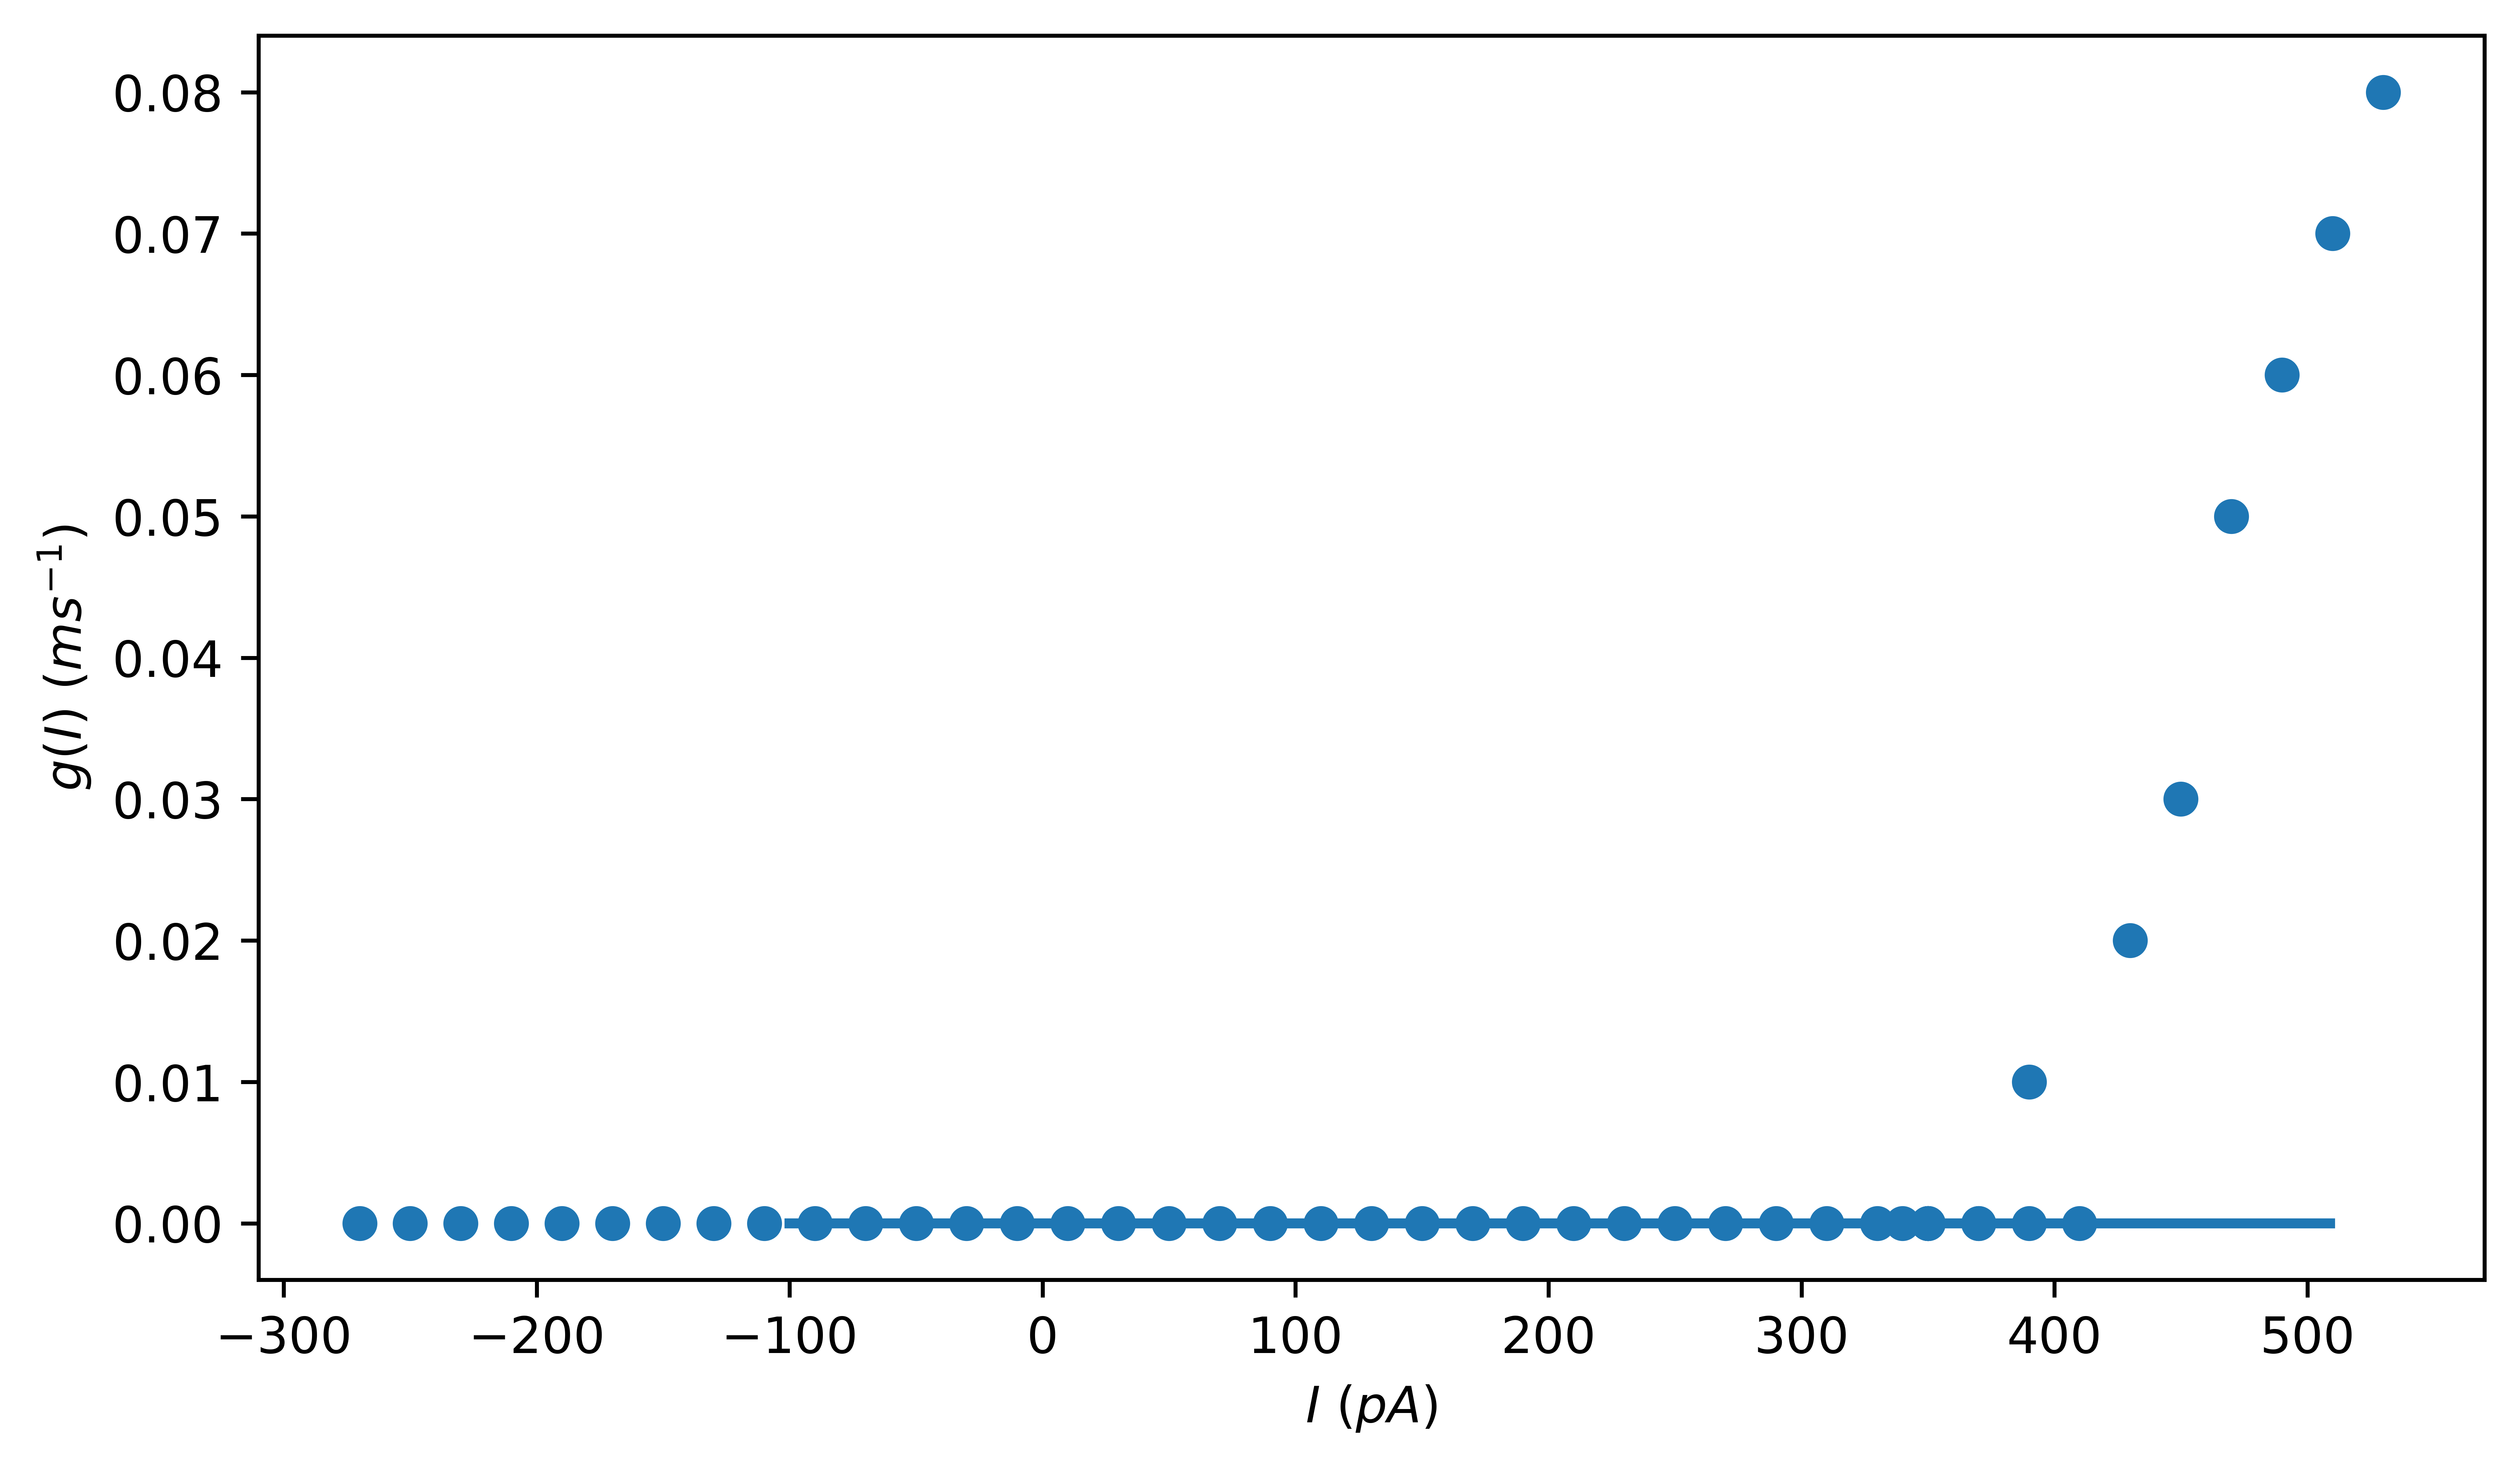

In [22]:
with open("data/activation_function/608108585_100_relu.pickle", "rb") as f:
    x = pickle.load(f)
if x["activation_params"]["type"] == "softplus":
    model = SoftplusActivation.from_params(x["activation_params"])
elif x["activation_params"]["type"] == "polynomial":
    model = PolynomialActivation.from_params(x["activation_params"])
elif x["activation_params"]["type"] == "relu":
    model = ReLUActivation.from_params(x["activation_params"])
elif x["activation_params"]["type"] == "sigmoid":
    model = SigmoidActivation.from_params(x["activation_params"])
activation_bin_size = x["activation_params"]["bin_size"]
cell_id = 341442651
data = get_data(cell_id)
Is_np, fs_np = preprocess_data(data, activation_bin_size)
Is = torch.tensor(Is_np)
fs = torch.tensor(fs_np)
plot_activation(Is, fs, model)

In [17]:
import matplotlib.pyplot as plt

def get_activation_plot(actv, start=-100, end=270):
    currents = torch.linspace(start, end, steps=300).reshape(-1, 1)
    with torch.no_grad():
        fs = actv(currents)
    return currents.reshape(-1), fs.reshape(-1)

def plot_activation(Is, fs, actv):
    # actv.max_current = torch.nn.Parameter(torch.tensor(float(torch.max(torch.abs(Is)))), requires_grad=False)
    plt.figure(figsize=(8, 4.5), dpi=1000)
    plt.scatter(Is, fs)
    xs1, ys1 = get_activation_plot(actv, end=int(actv.max_current)+300)
    plt.plot(xs1, ys1, linewidth=2)
    plt.xlabel("$I$ $(pA)$")
    plt.ylabel("$g(I)$ $(ms^{-1})$")

{'type': 'polynomial', 'degree': 2, 'max_current': 349.9825134277344, 'max_firing_rate': 0.15847860538829395, 'poly_coeff': [[-2.907250940705964e-23, -7.781375087286719e-23, 0.5600489377975464]], 'b': [19.804716110229492], 'bin_size': 100}
{'type': 'polynomial', 'degree': 2, 'max_current': 249.94998168945312, 'max_firing_rate': 0.05296610169491523, 'poly_coeff': [[5.129021750022764e-25, 0.7804824709892273, -0.9888947010040283]], 'b': [44.003902435302734], 'bin_size': 100}
{'type': 'polynomial', 'degree': 2, 'max_current': 289.9855041503906, 'max_firing_rate': 0.07328691828508423, 'poly_coeff': [[-1.3525271077782108e-23, 0.35457614064216614, -0.622794508934021]], 'b': [33.39722442626953], 'bin_size': 100}
{'type': 'polynomial', 'degree': 2, 'max_current': 269.9460144042969, 'max_firing_rate': 0.21186440677965843, 'poly_coeff': [[-1.674459192160552e-23, -5.16649540403393e-24, -0.7031058073043823]], 'b': [7.6808342933654785], 'bin_size': 100}
{'type': 'polynomial', 'degree': 2, 'max_curre

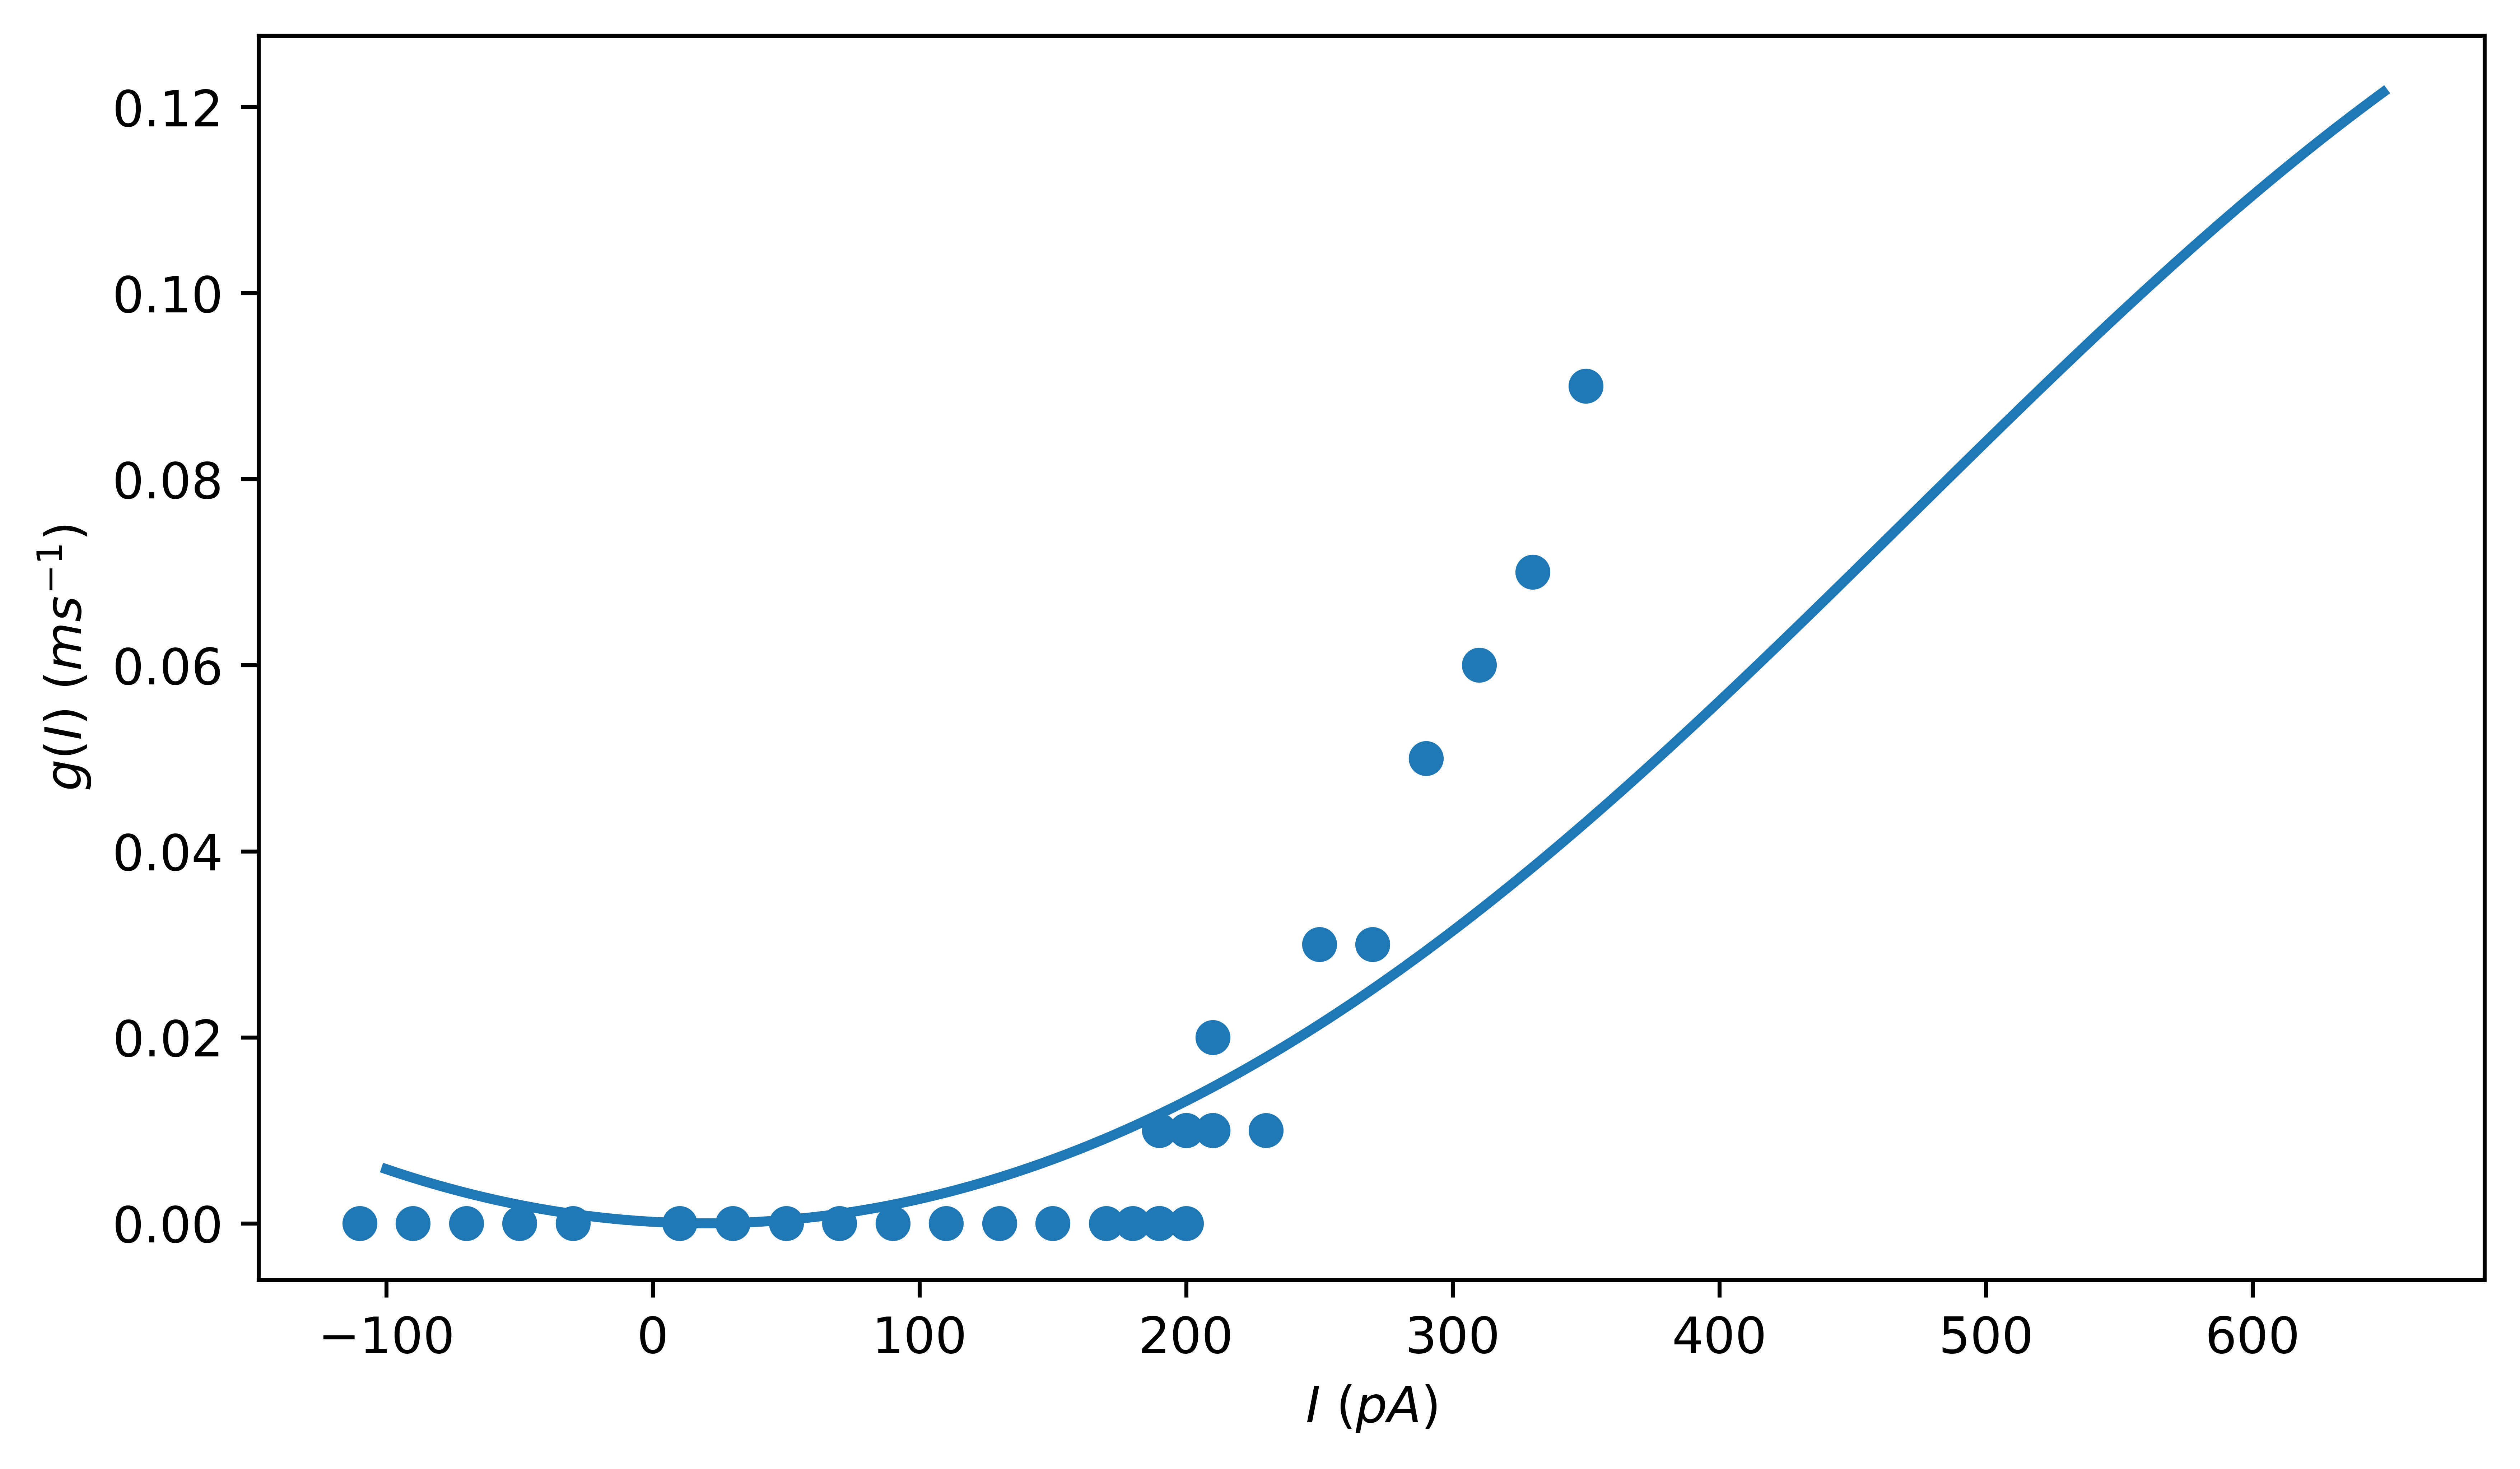

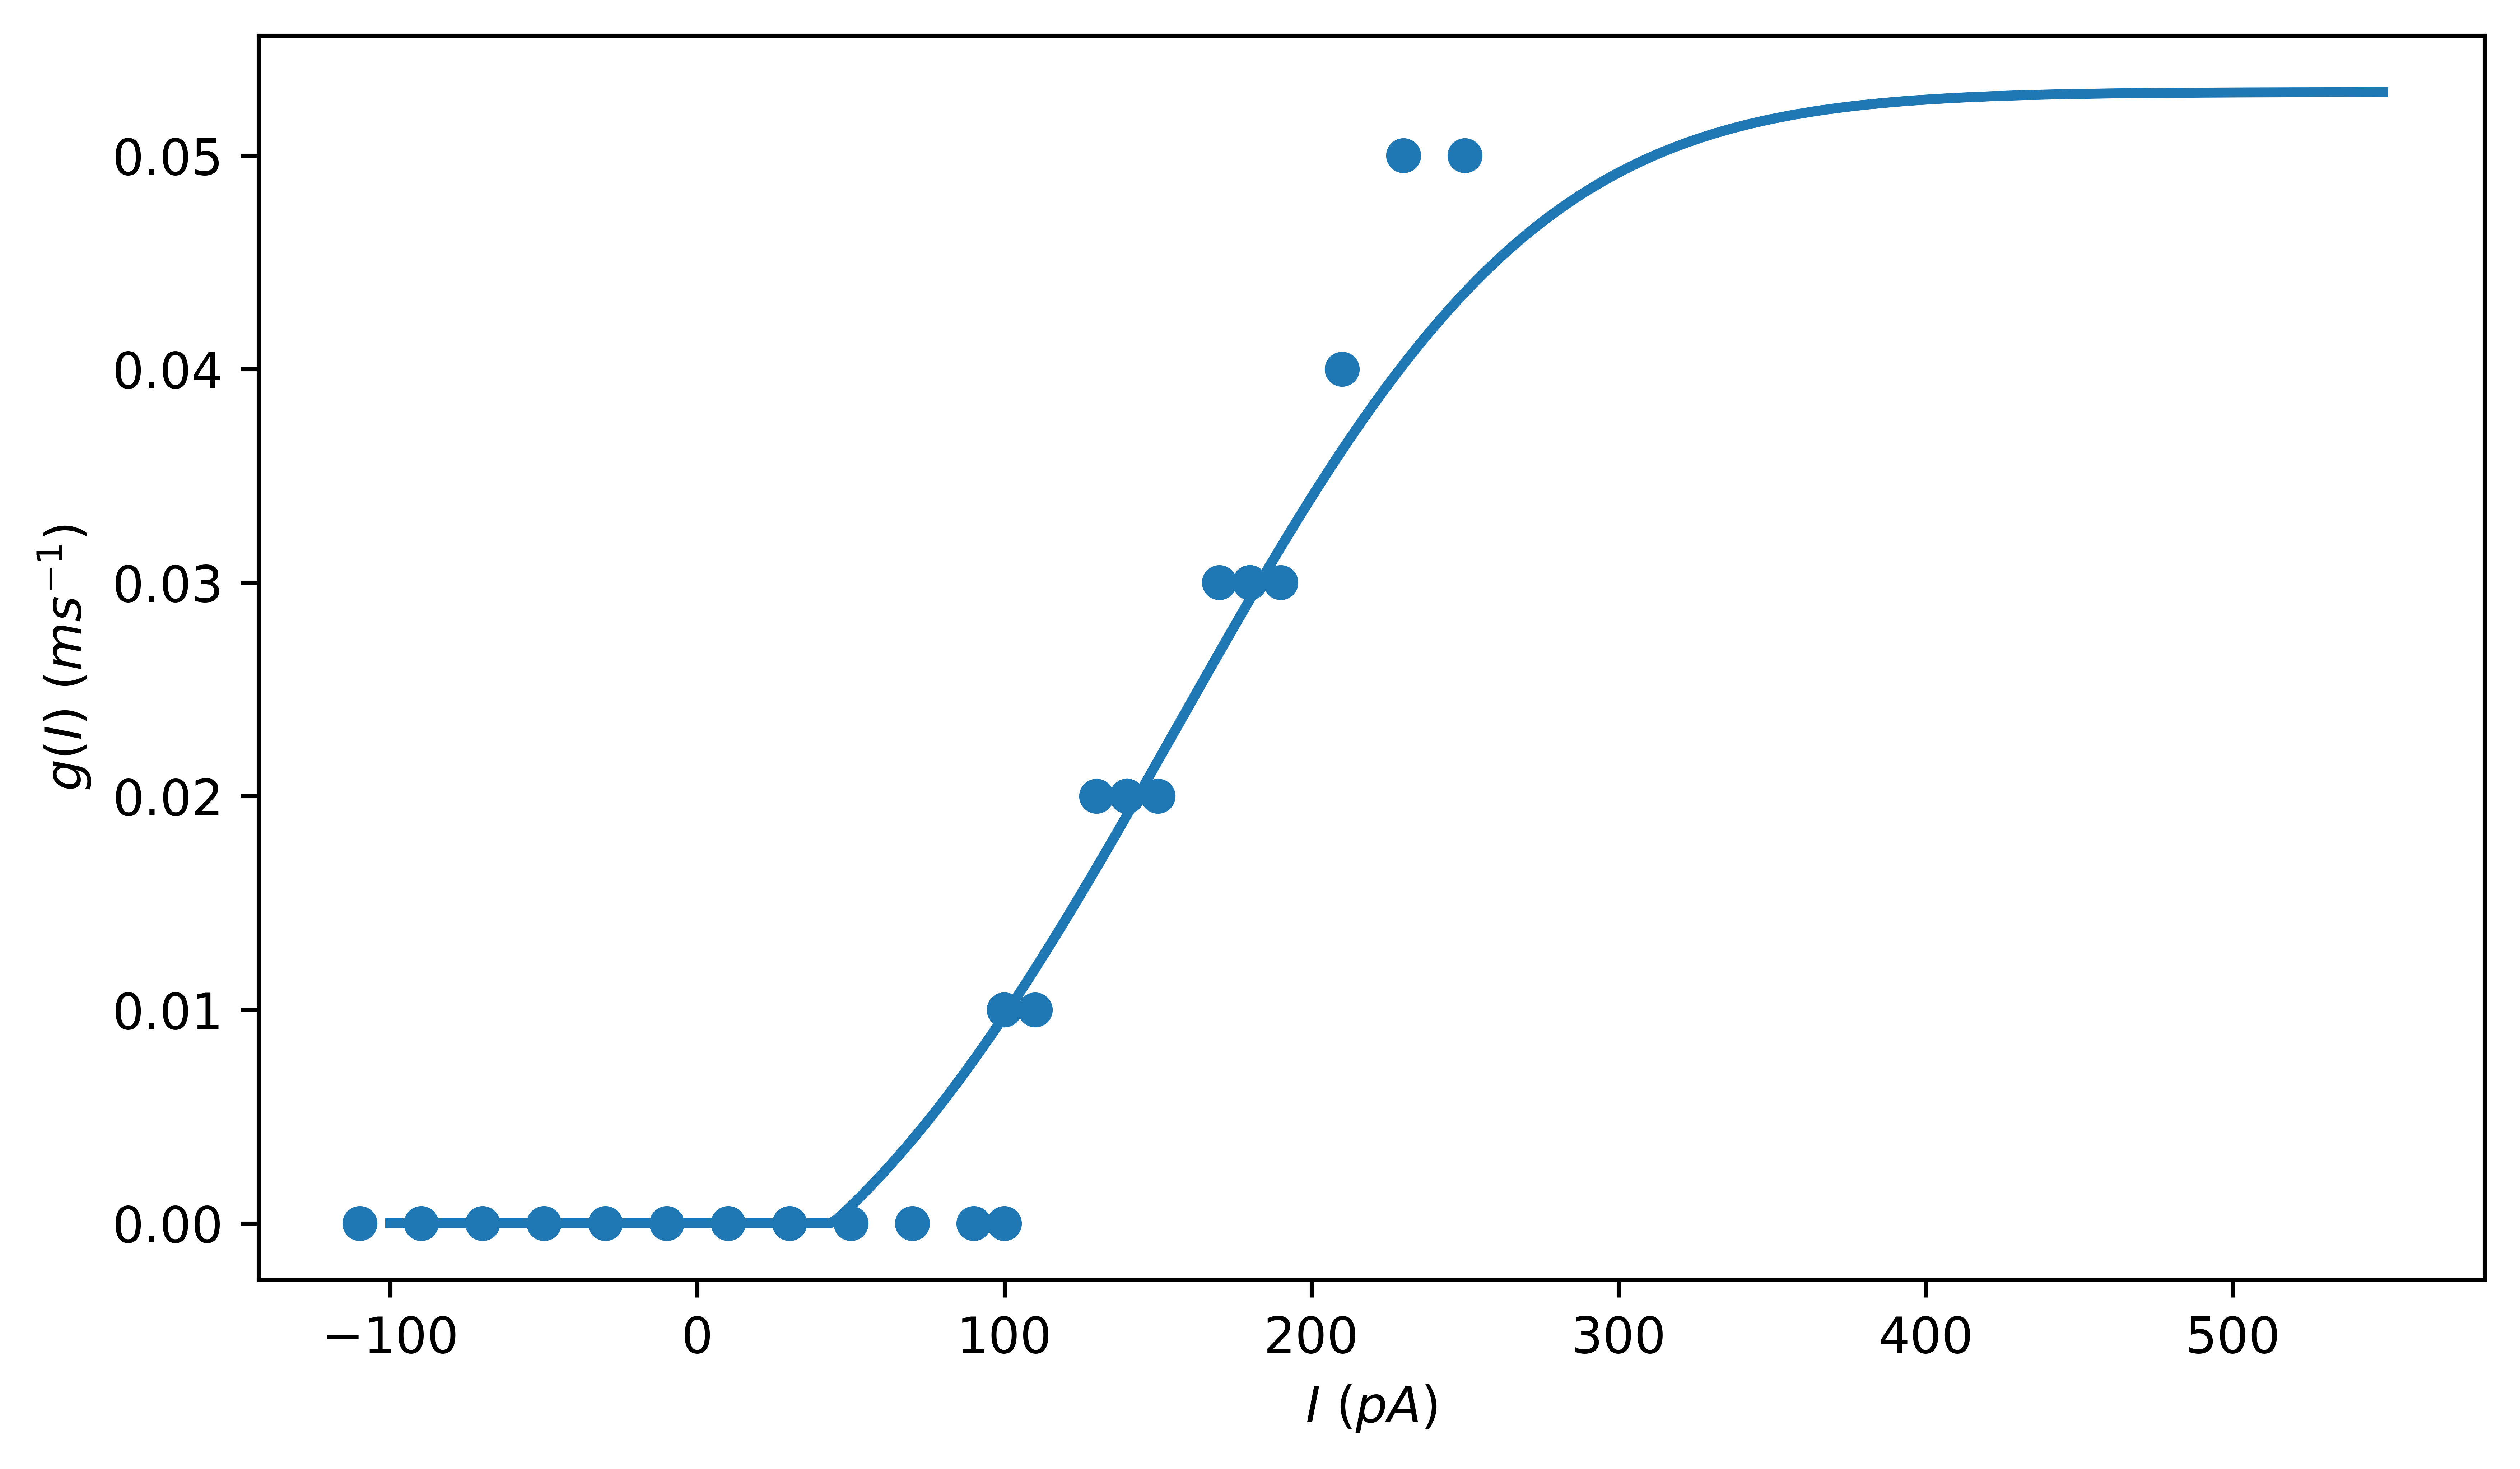

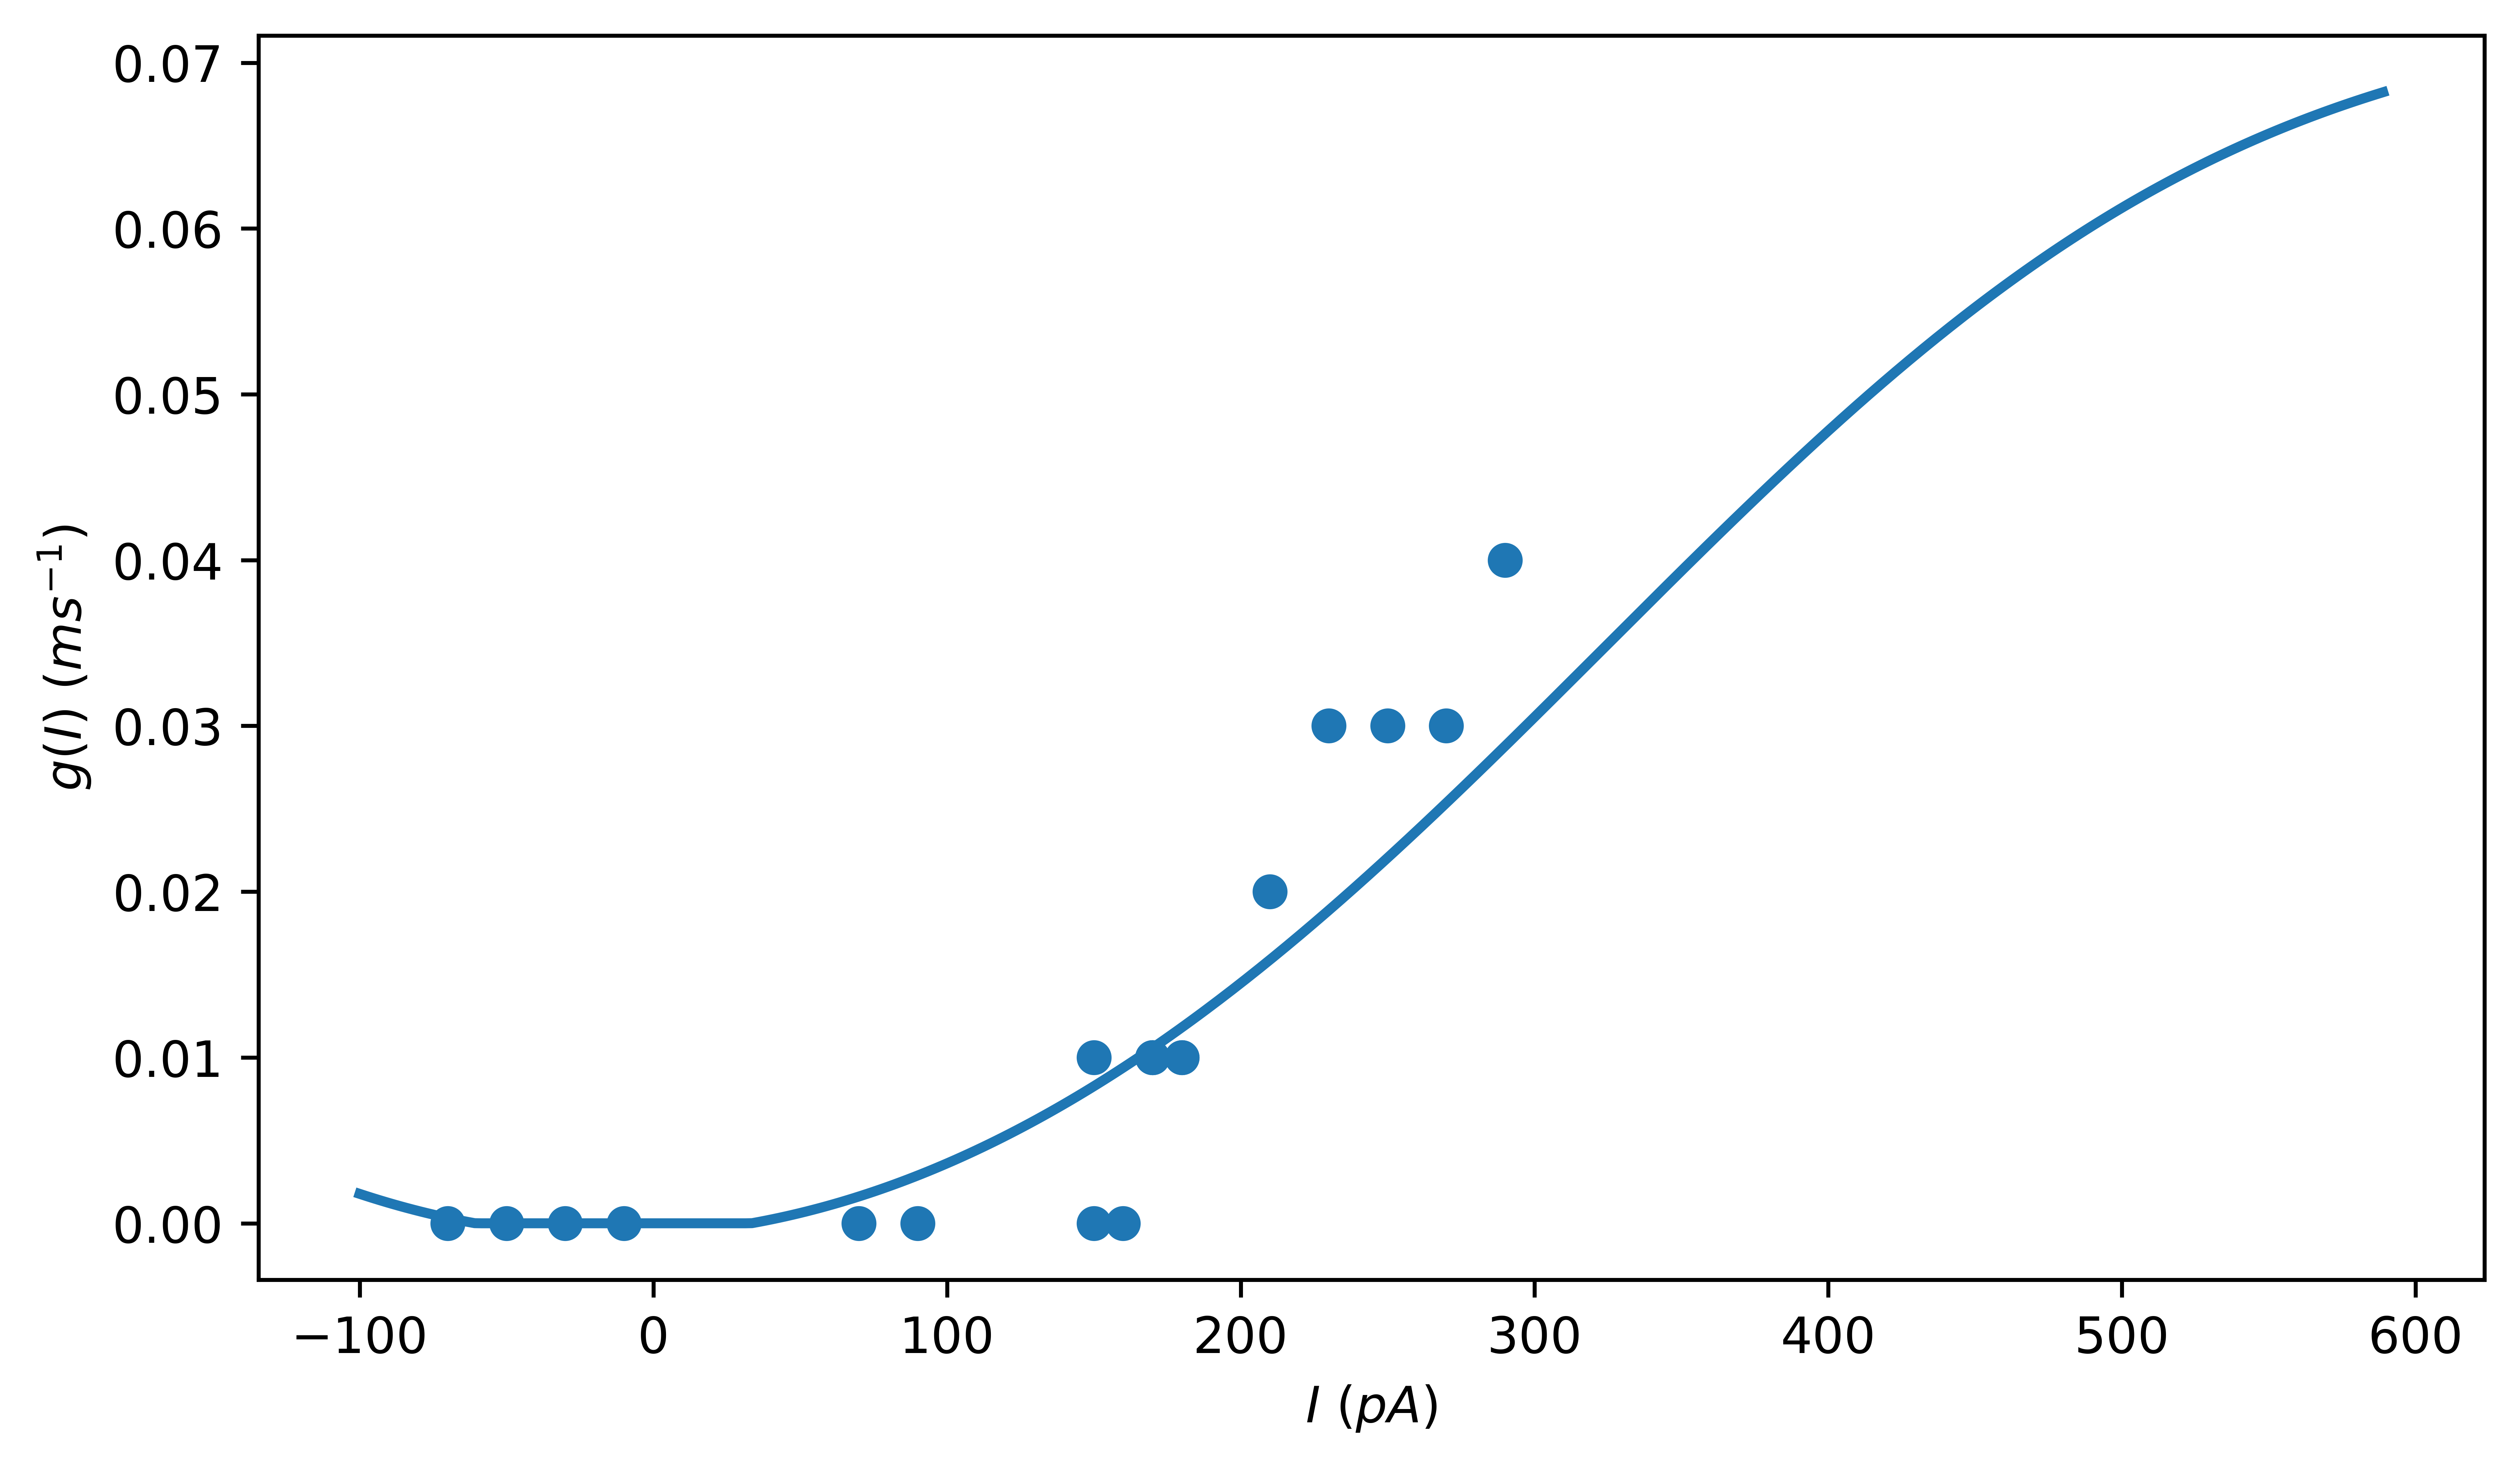

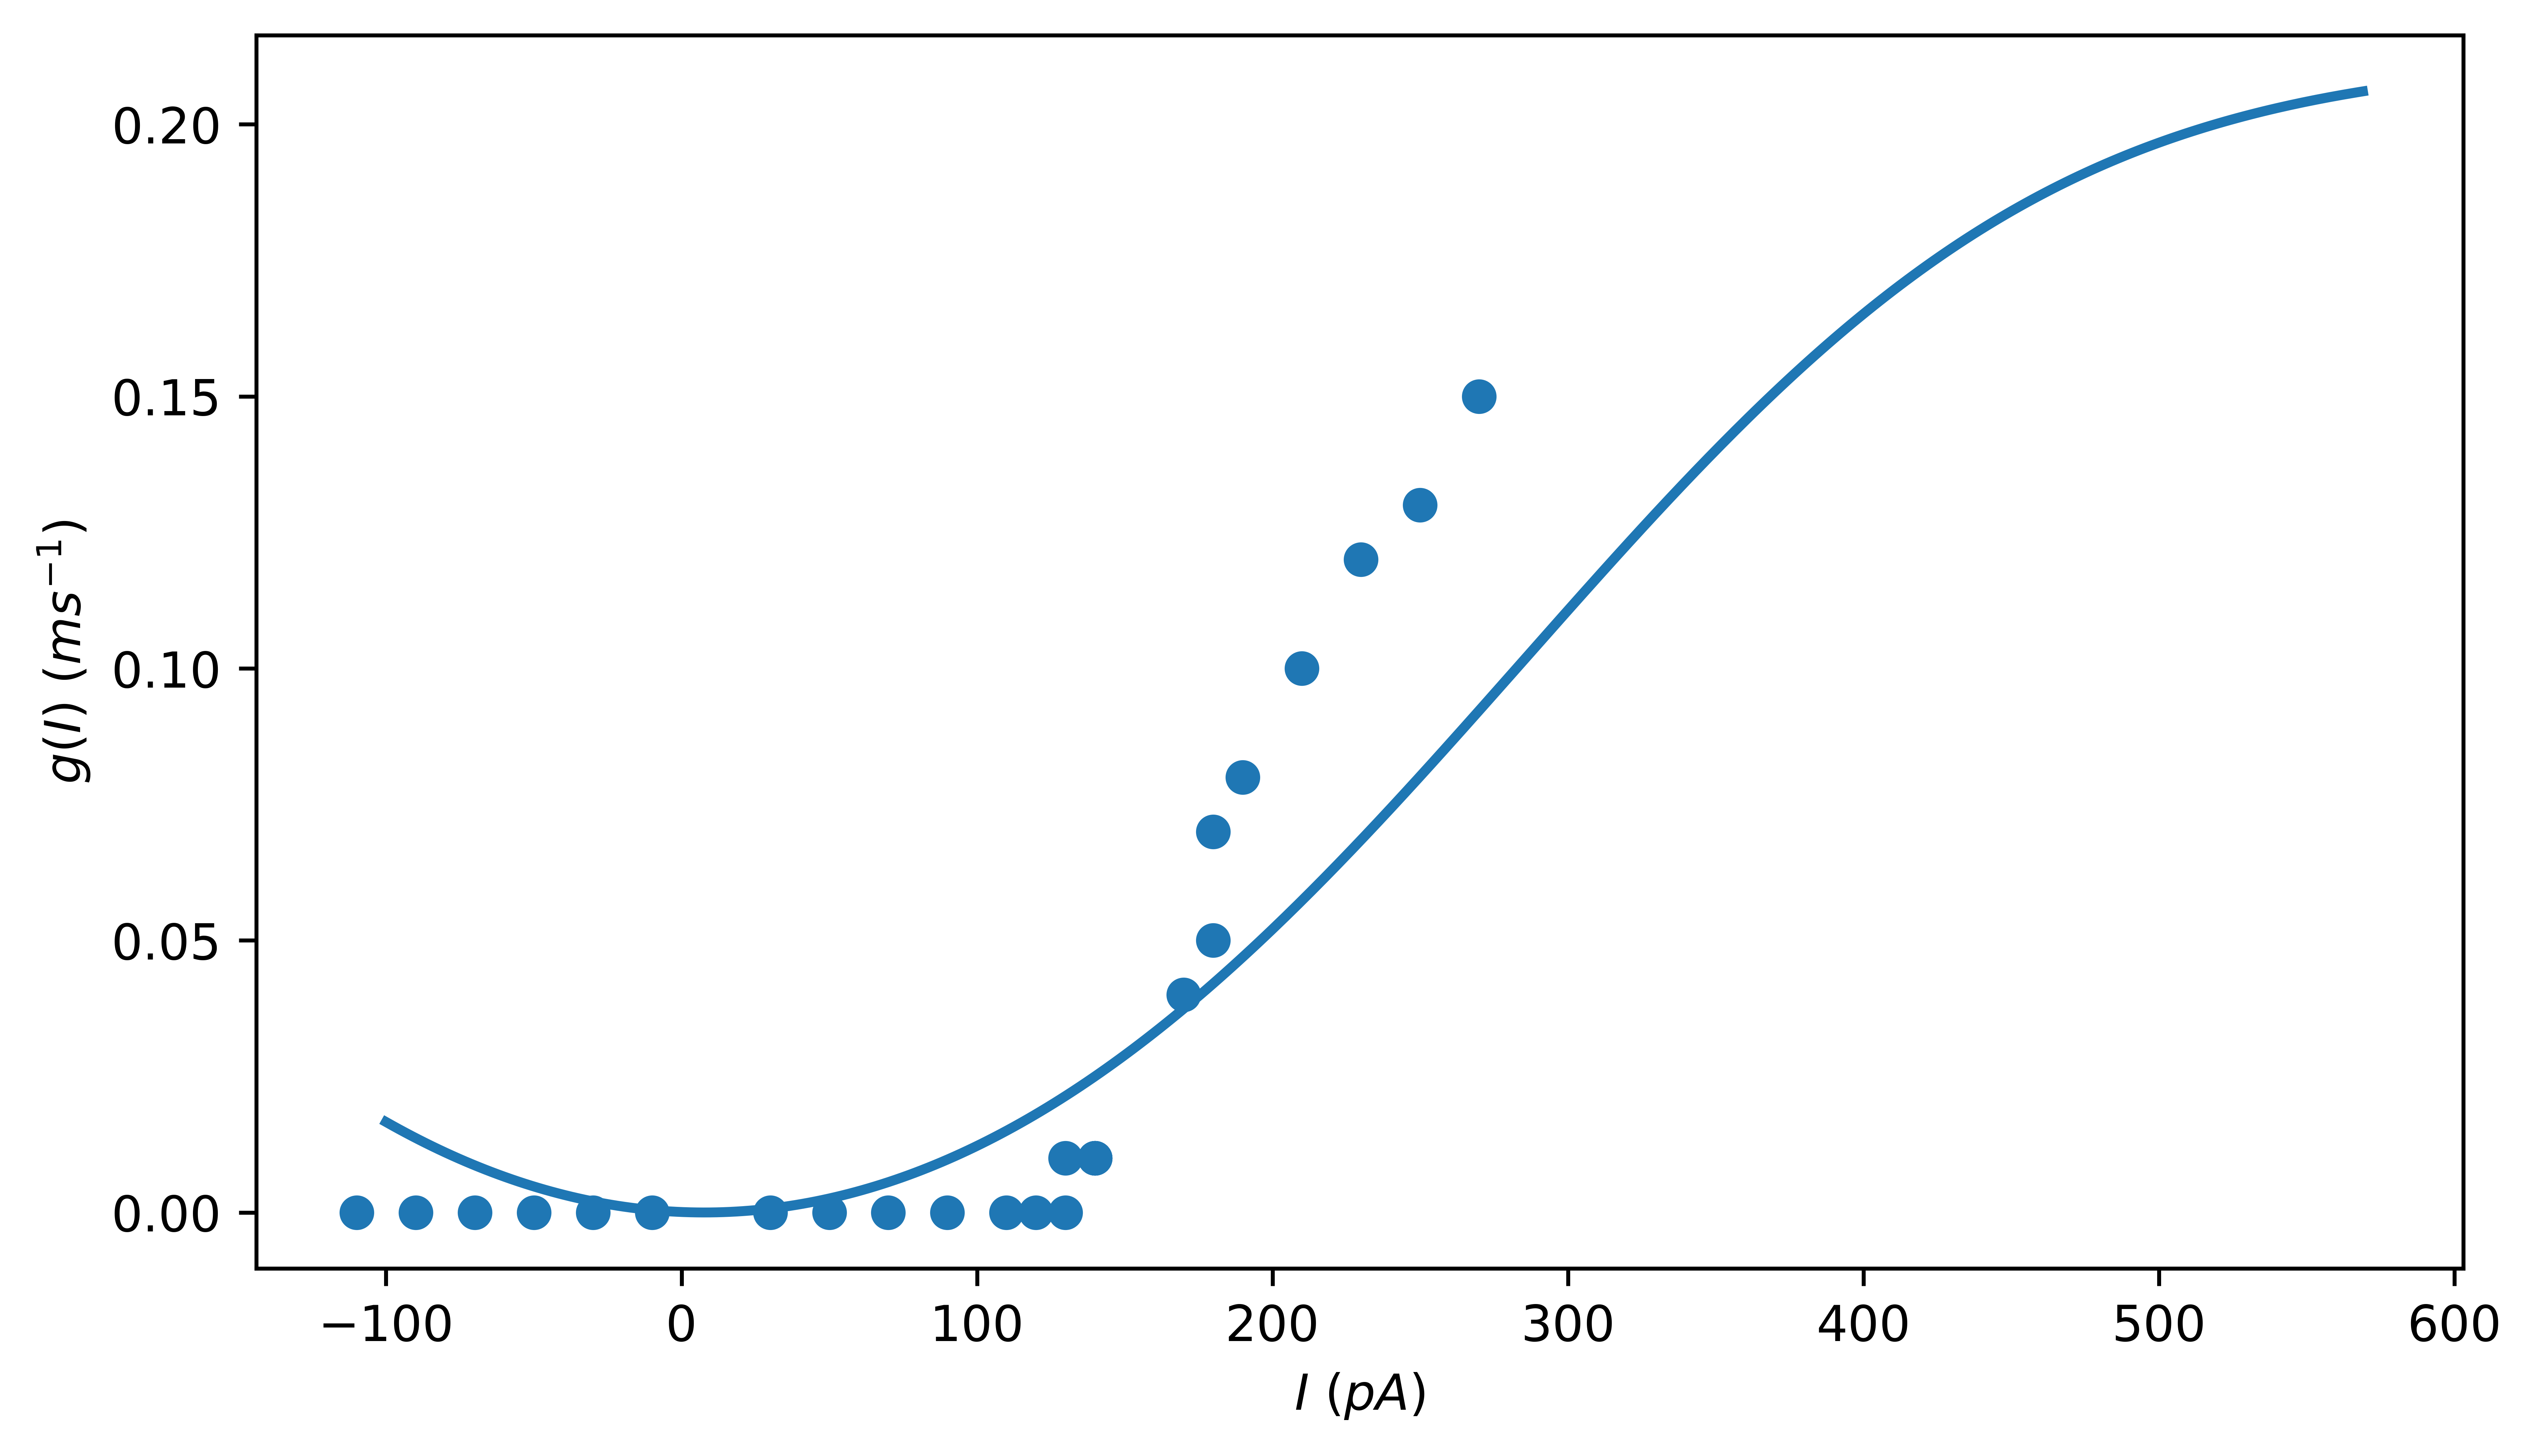

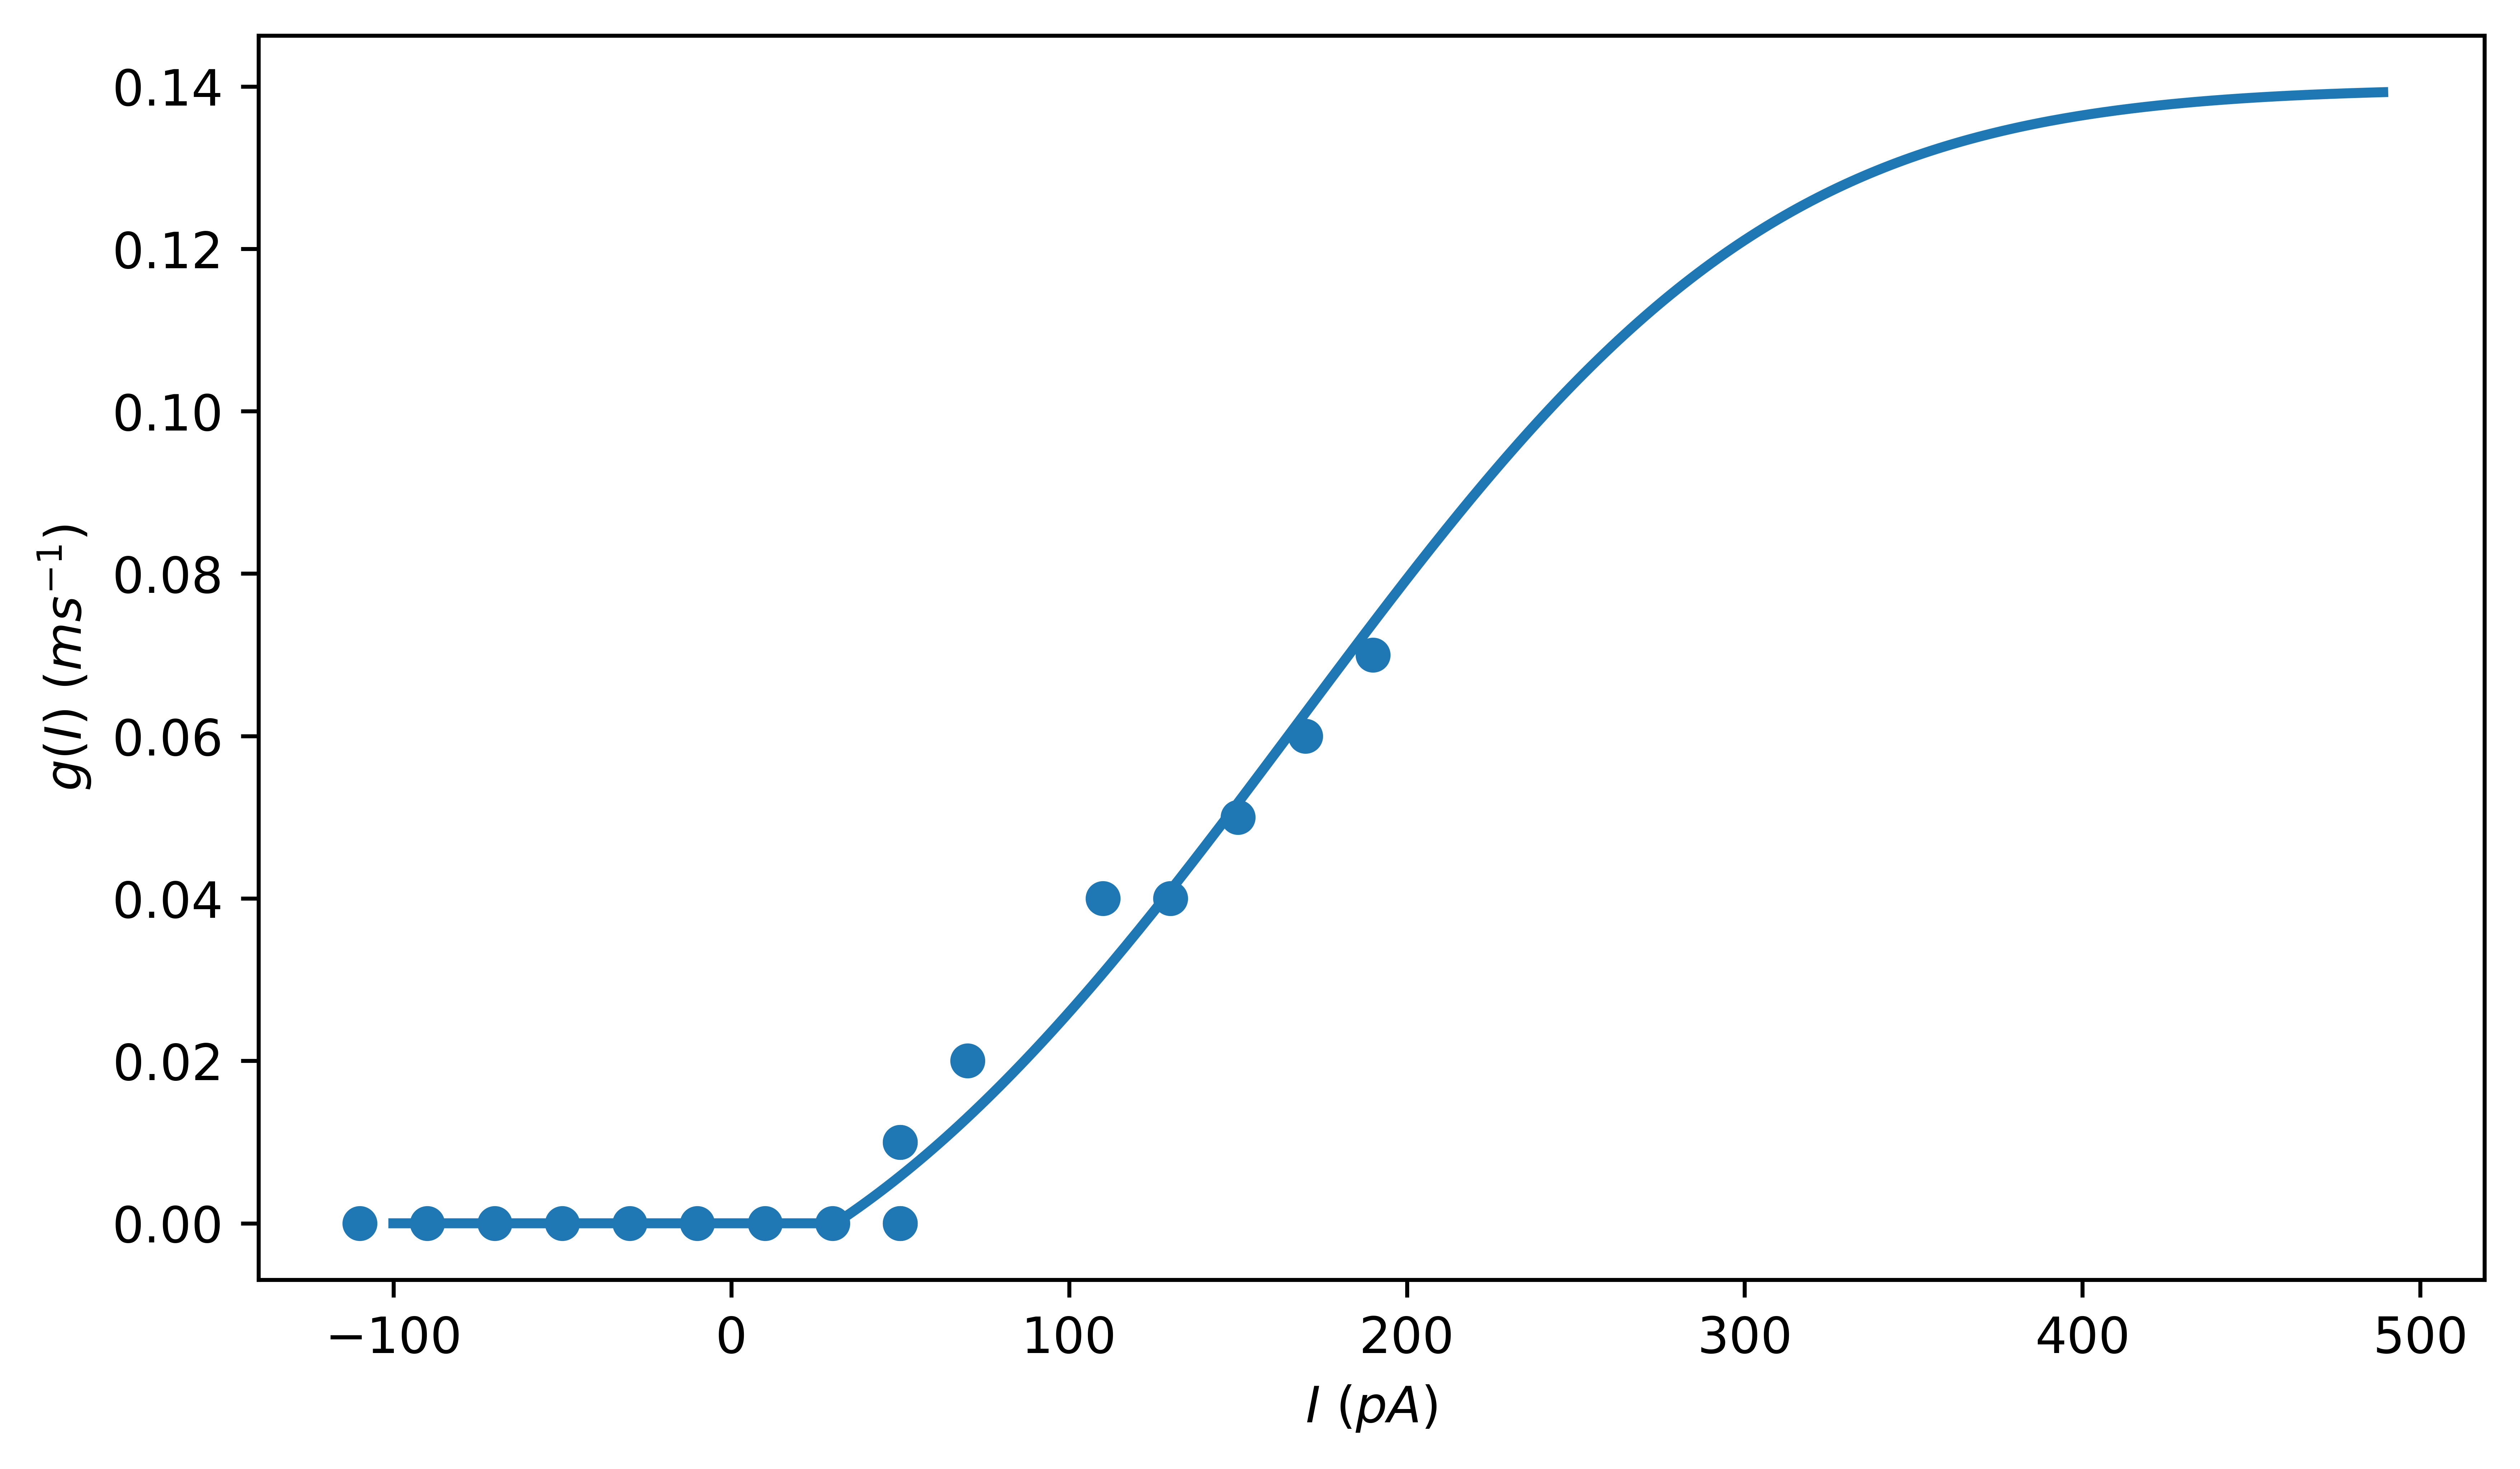

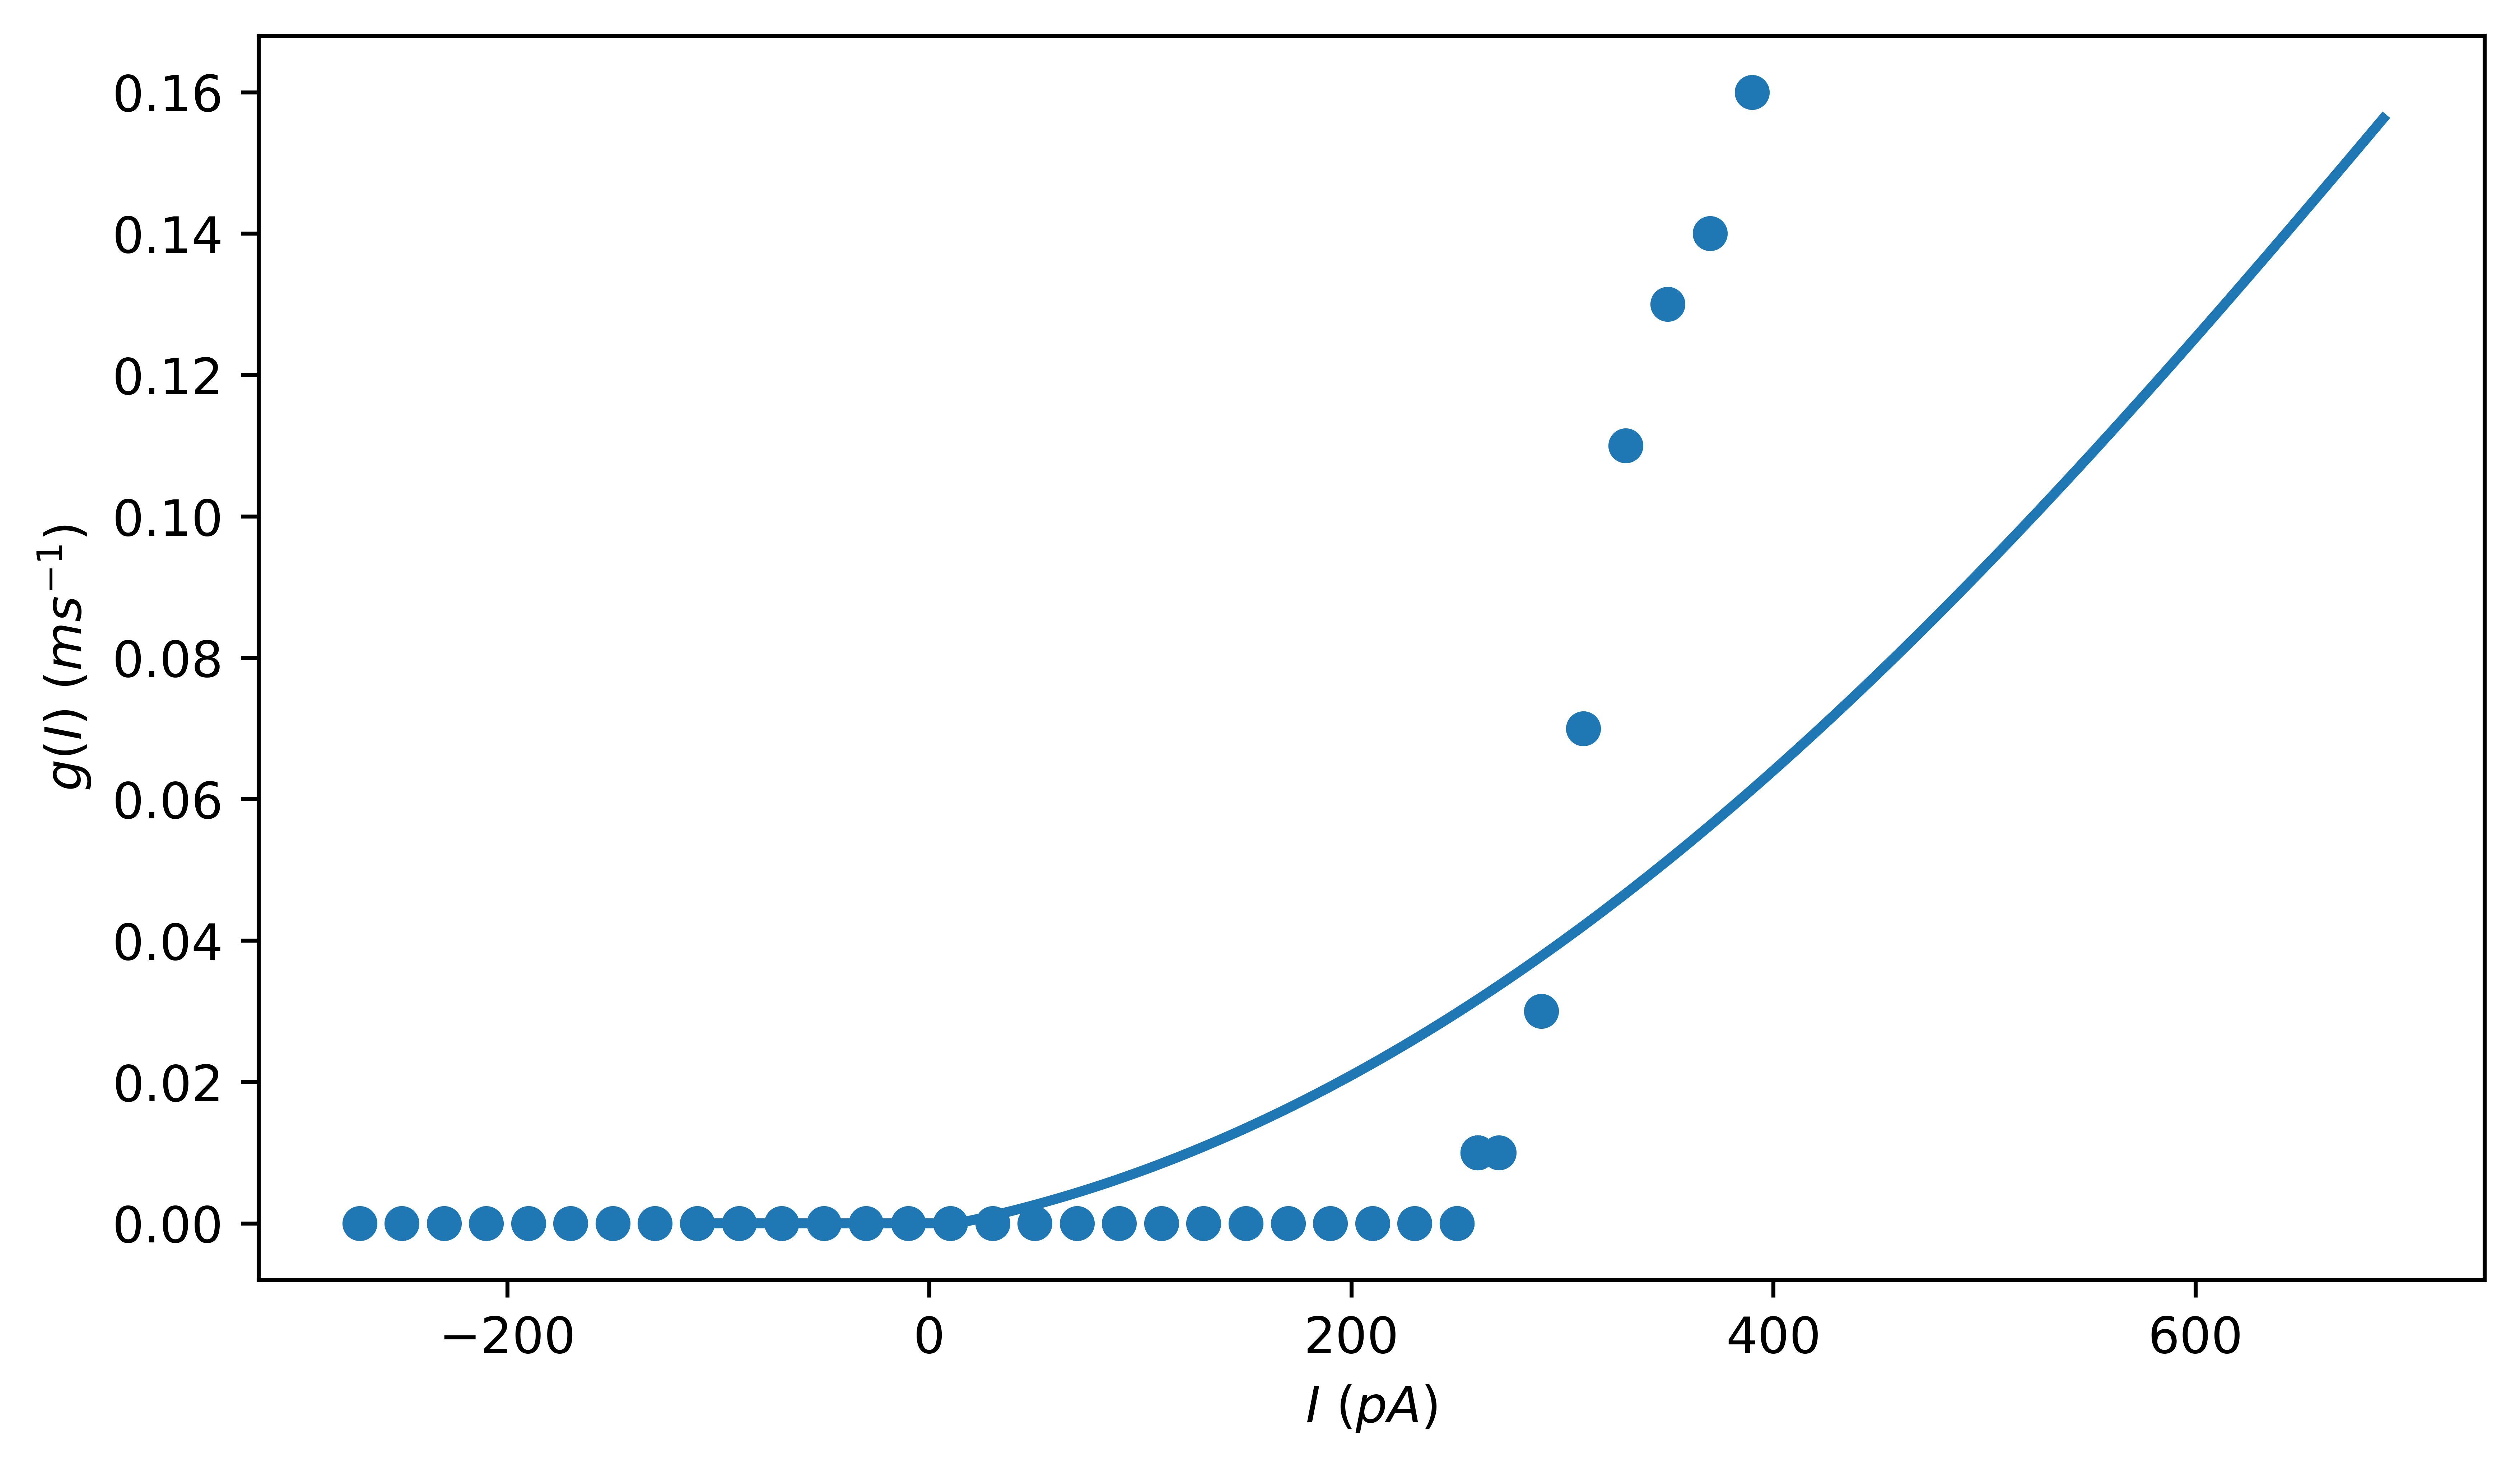

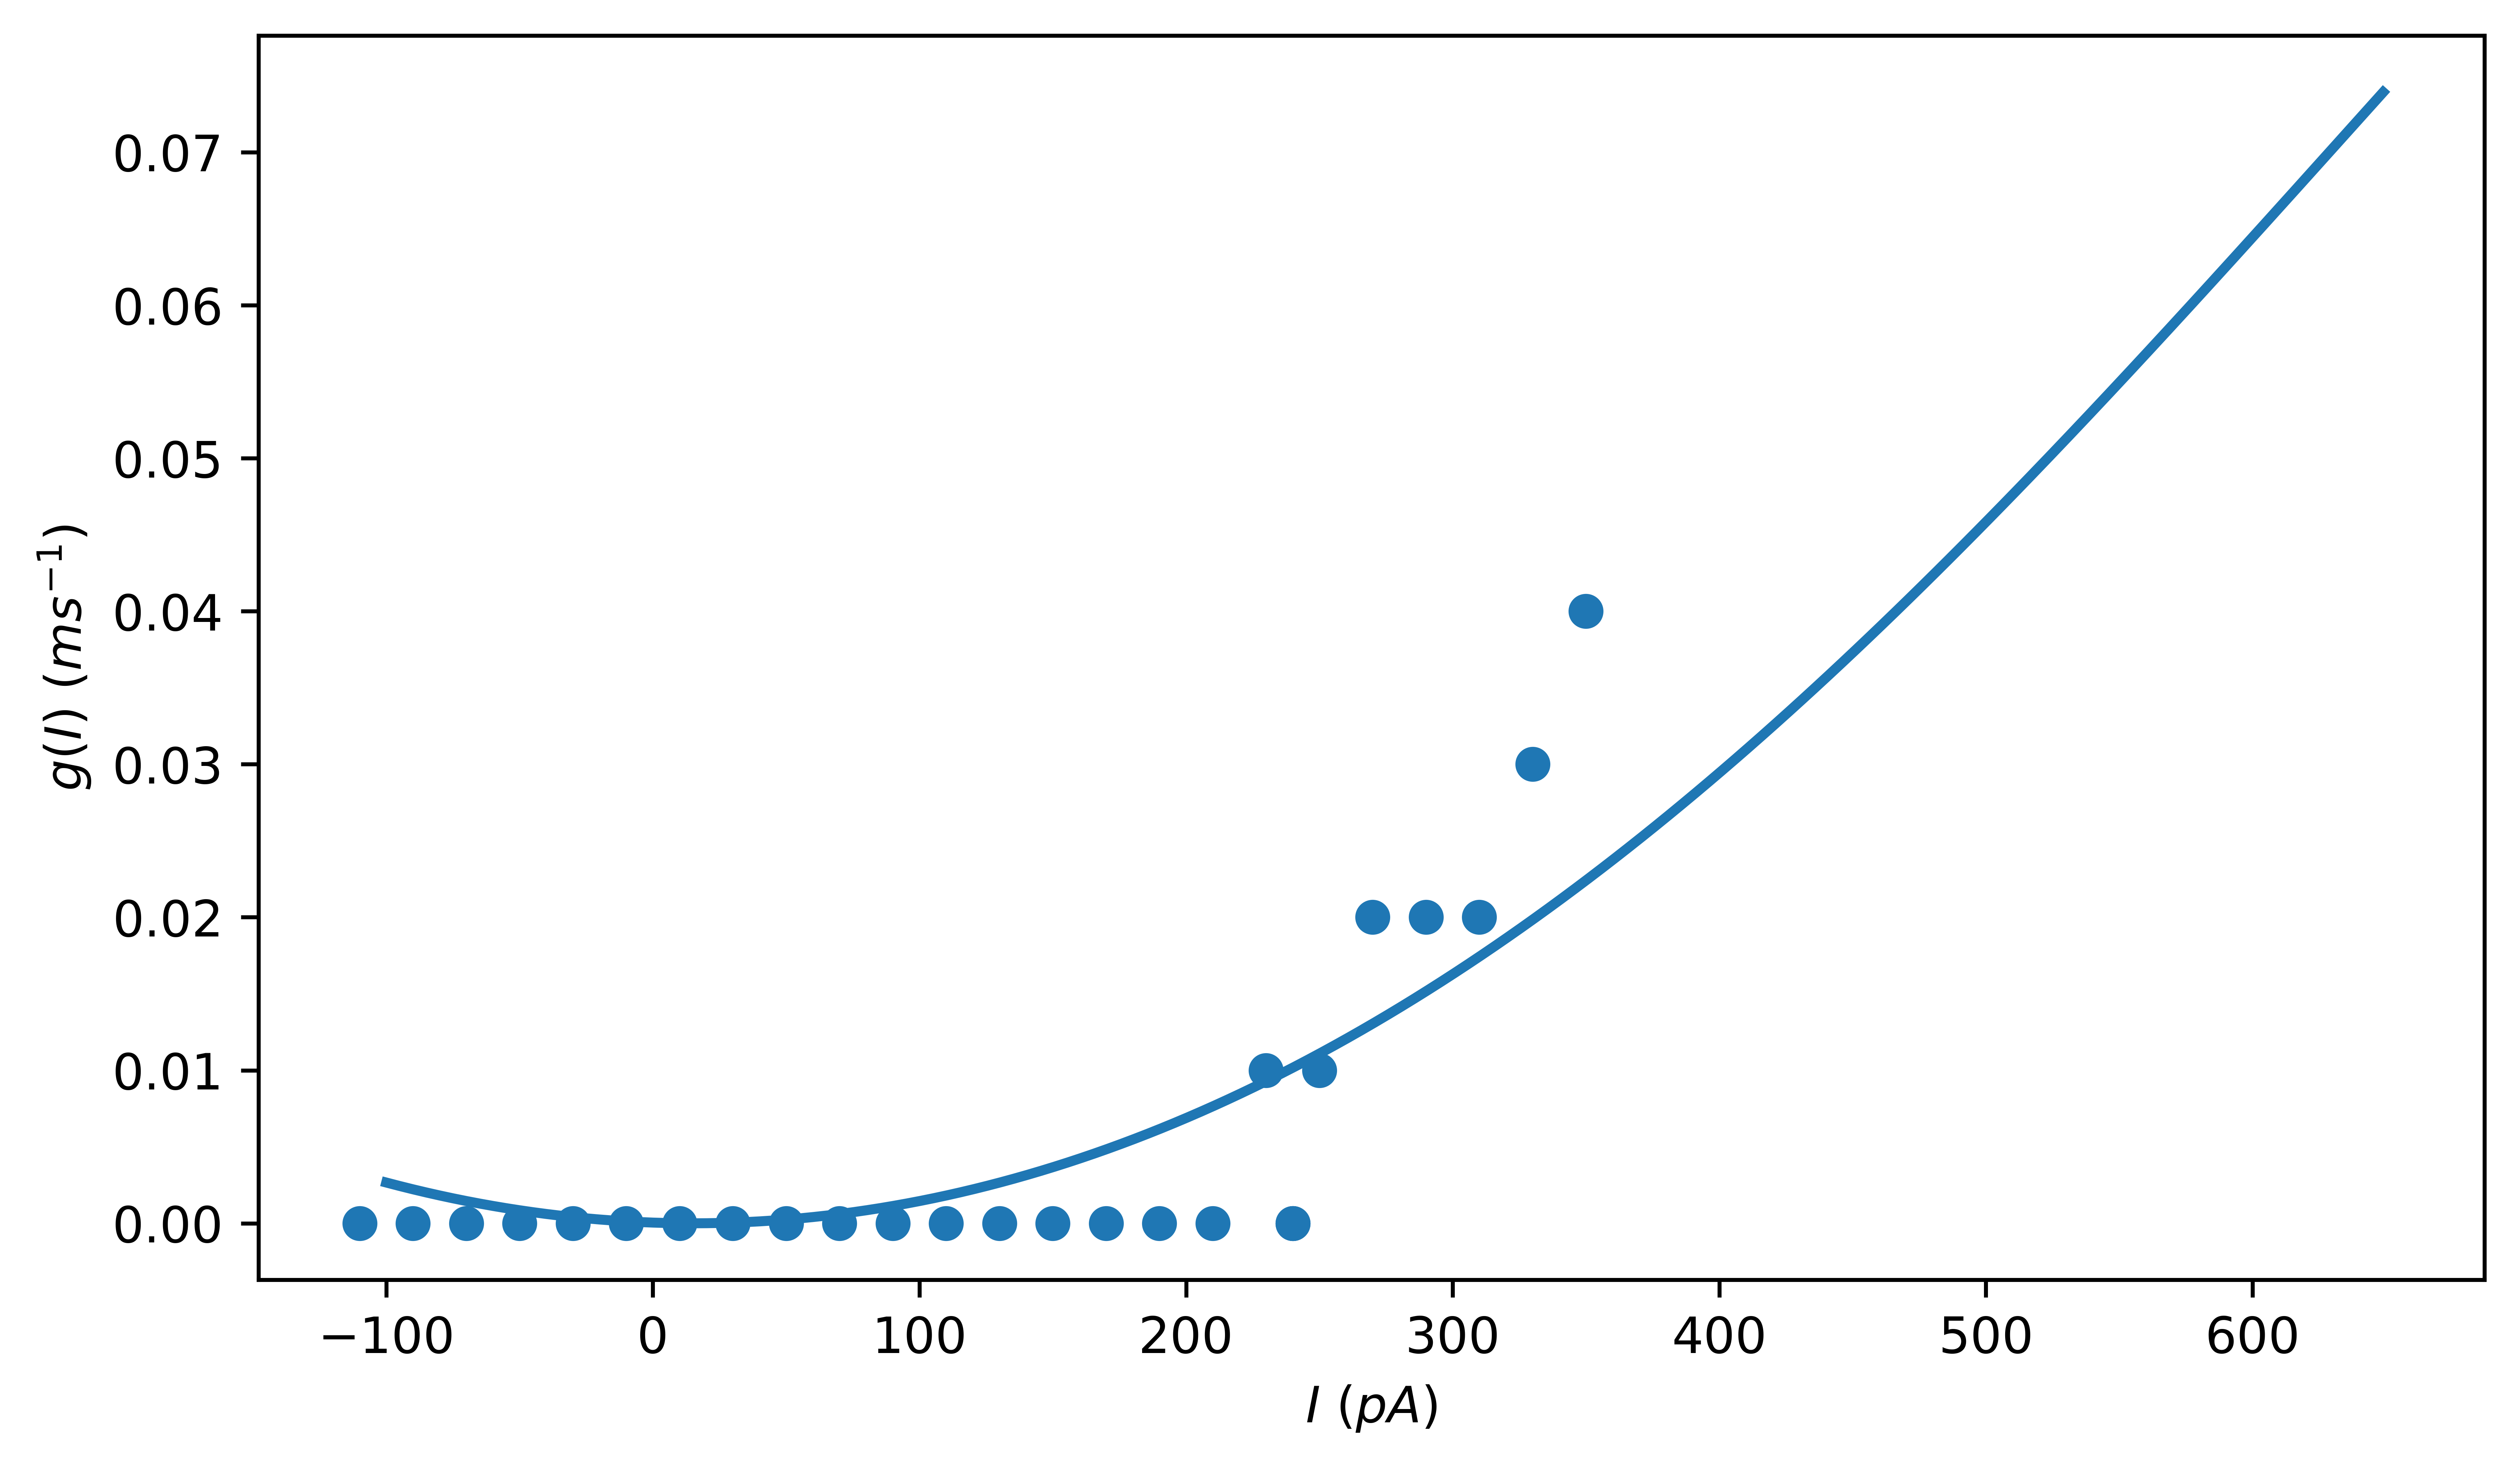

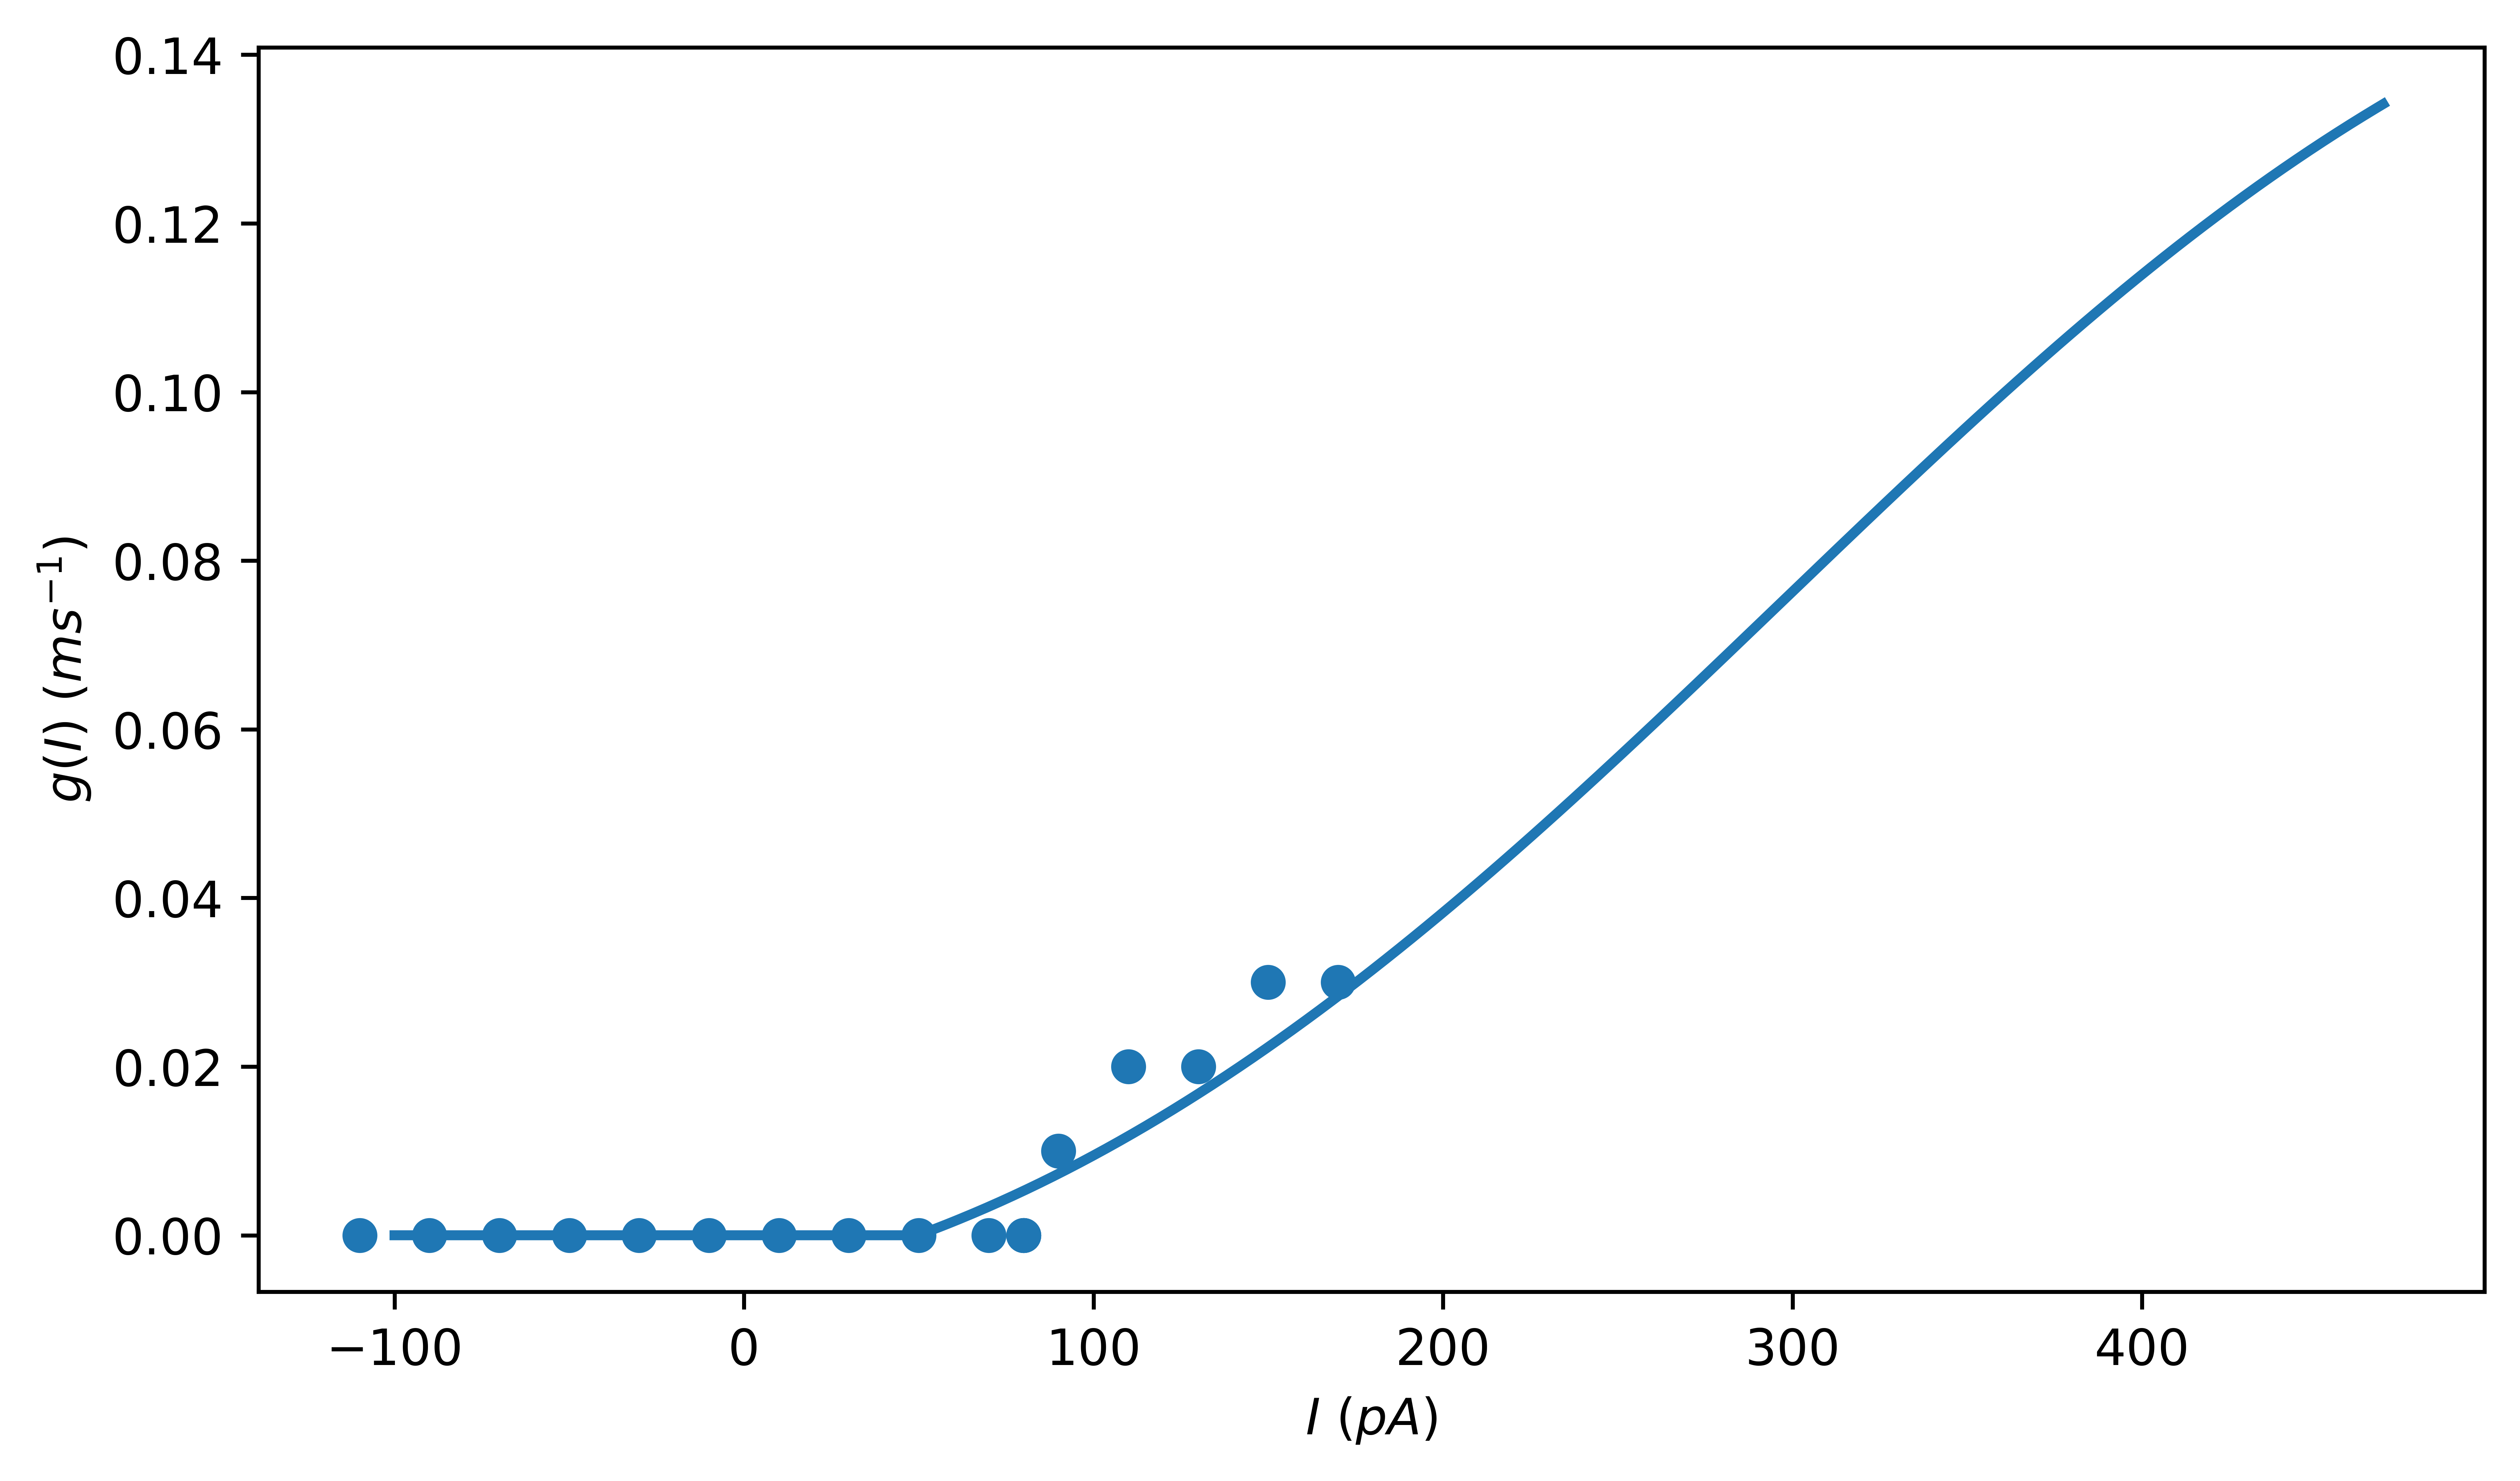

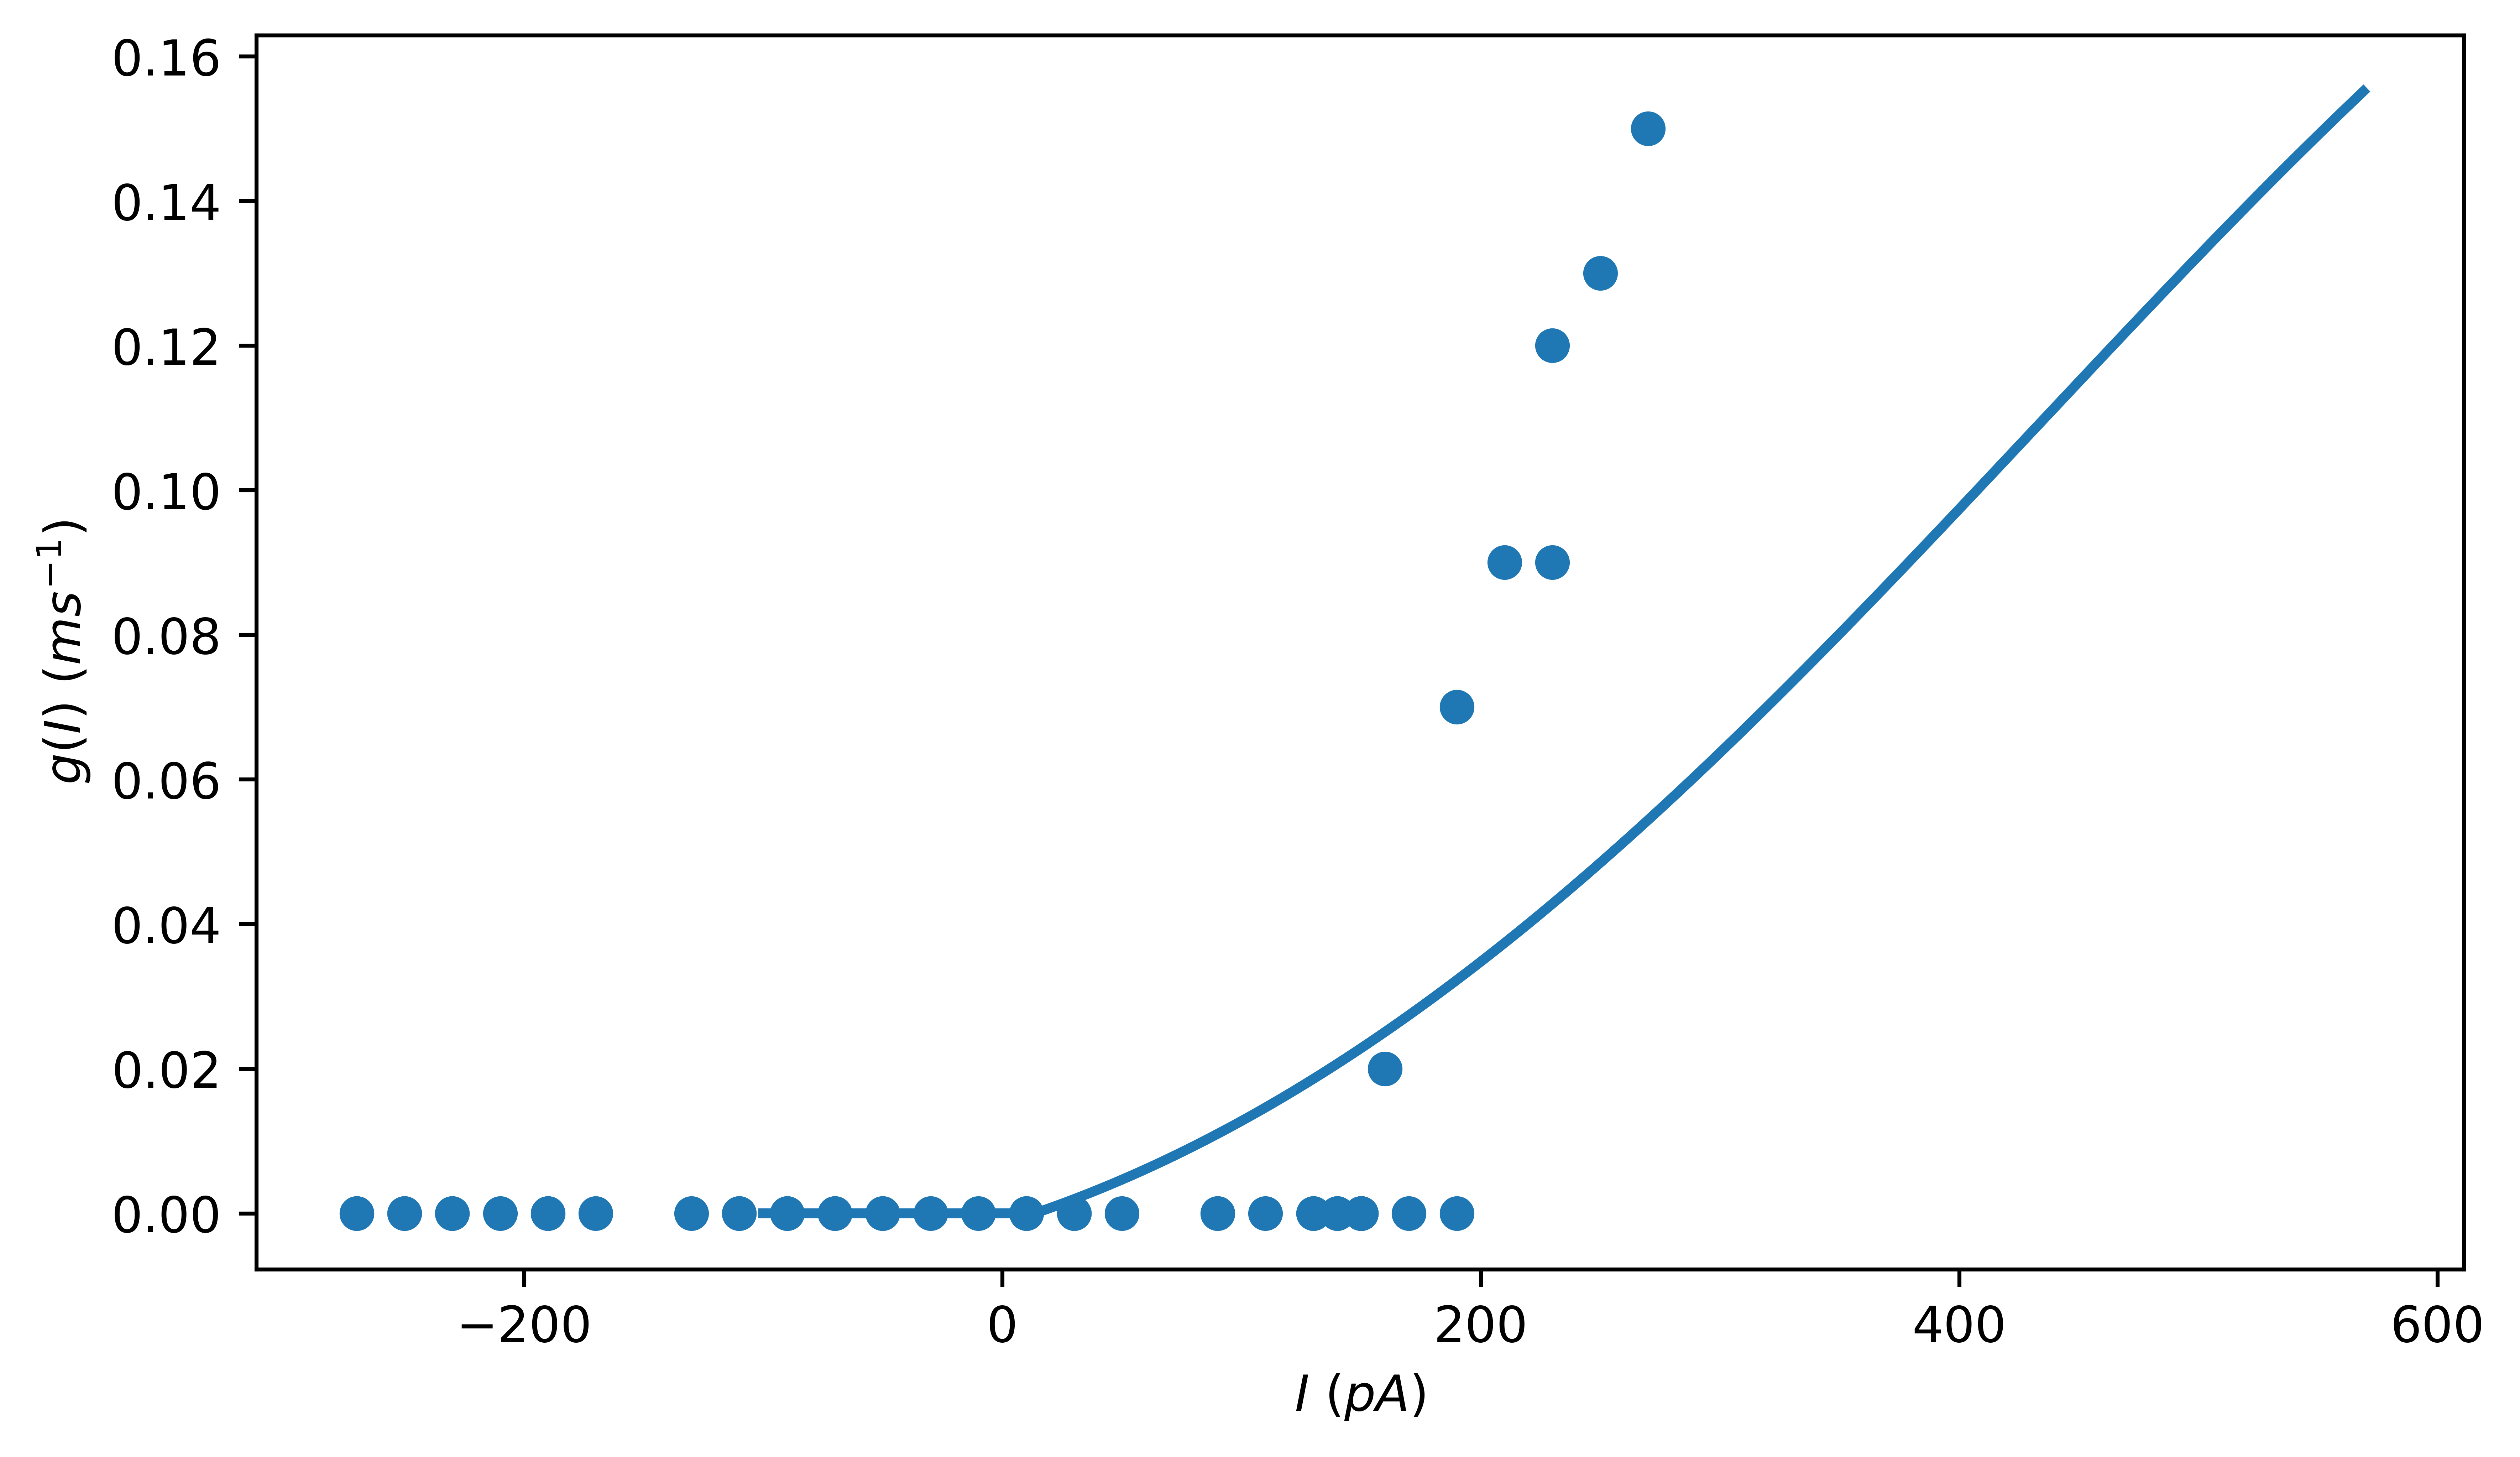

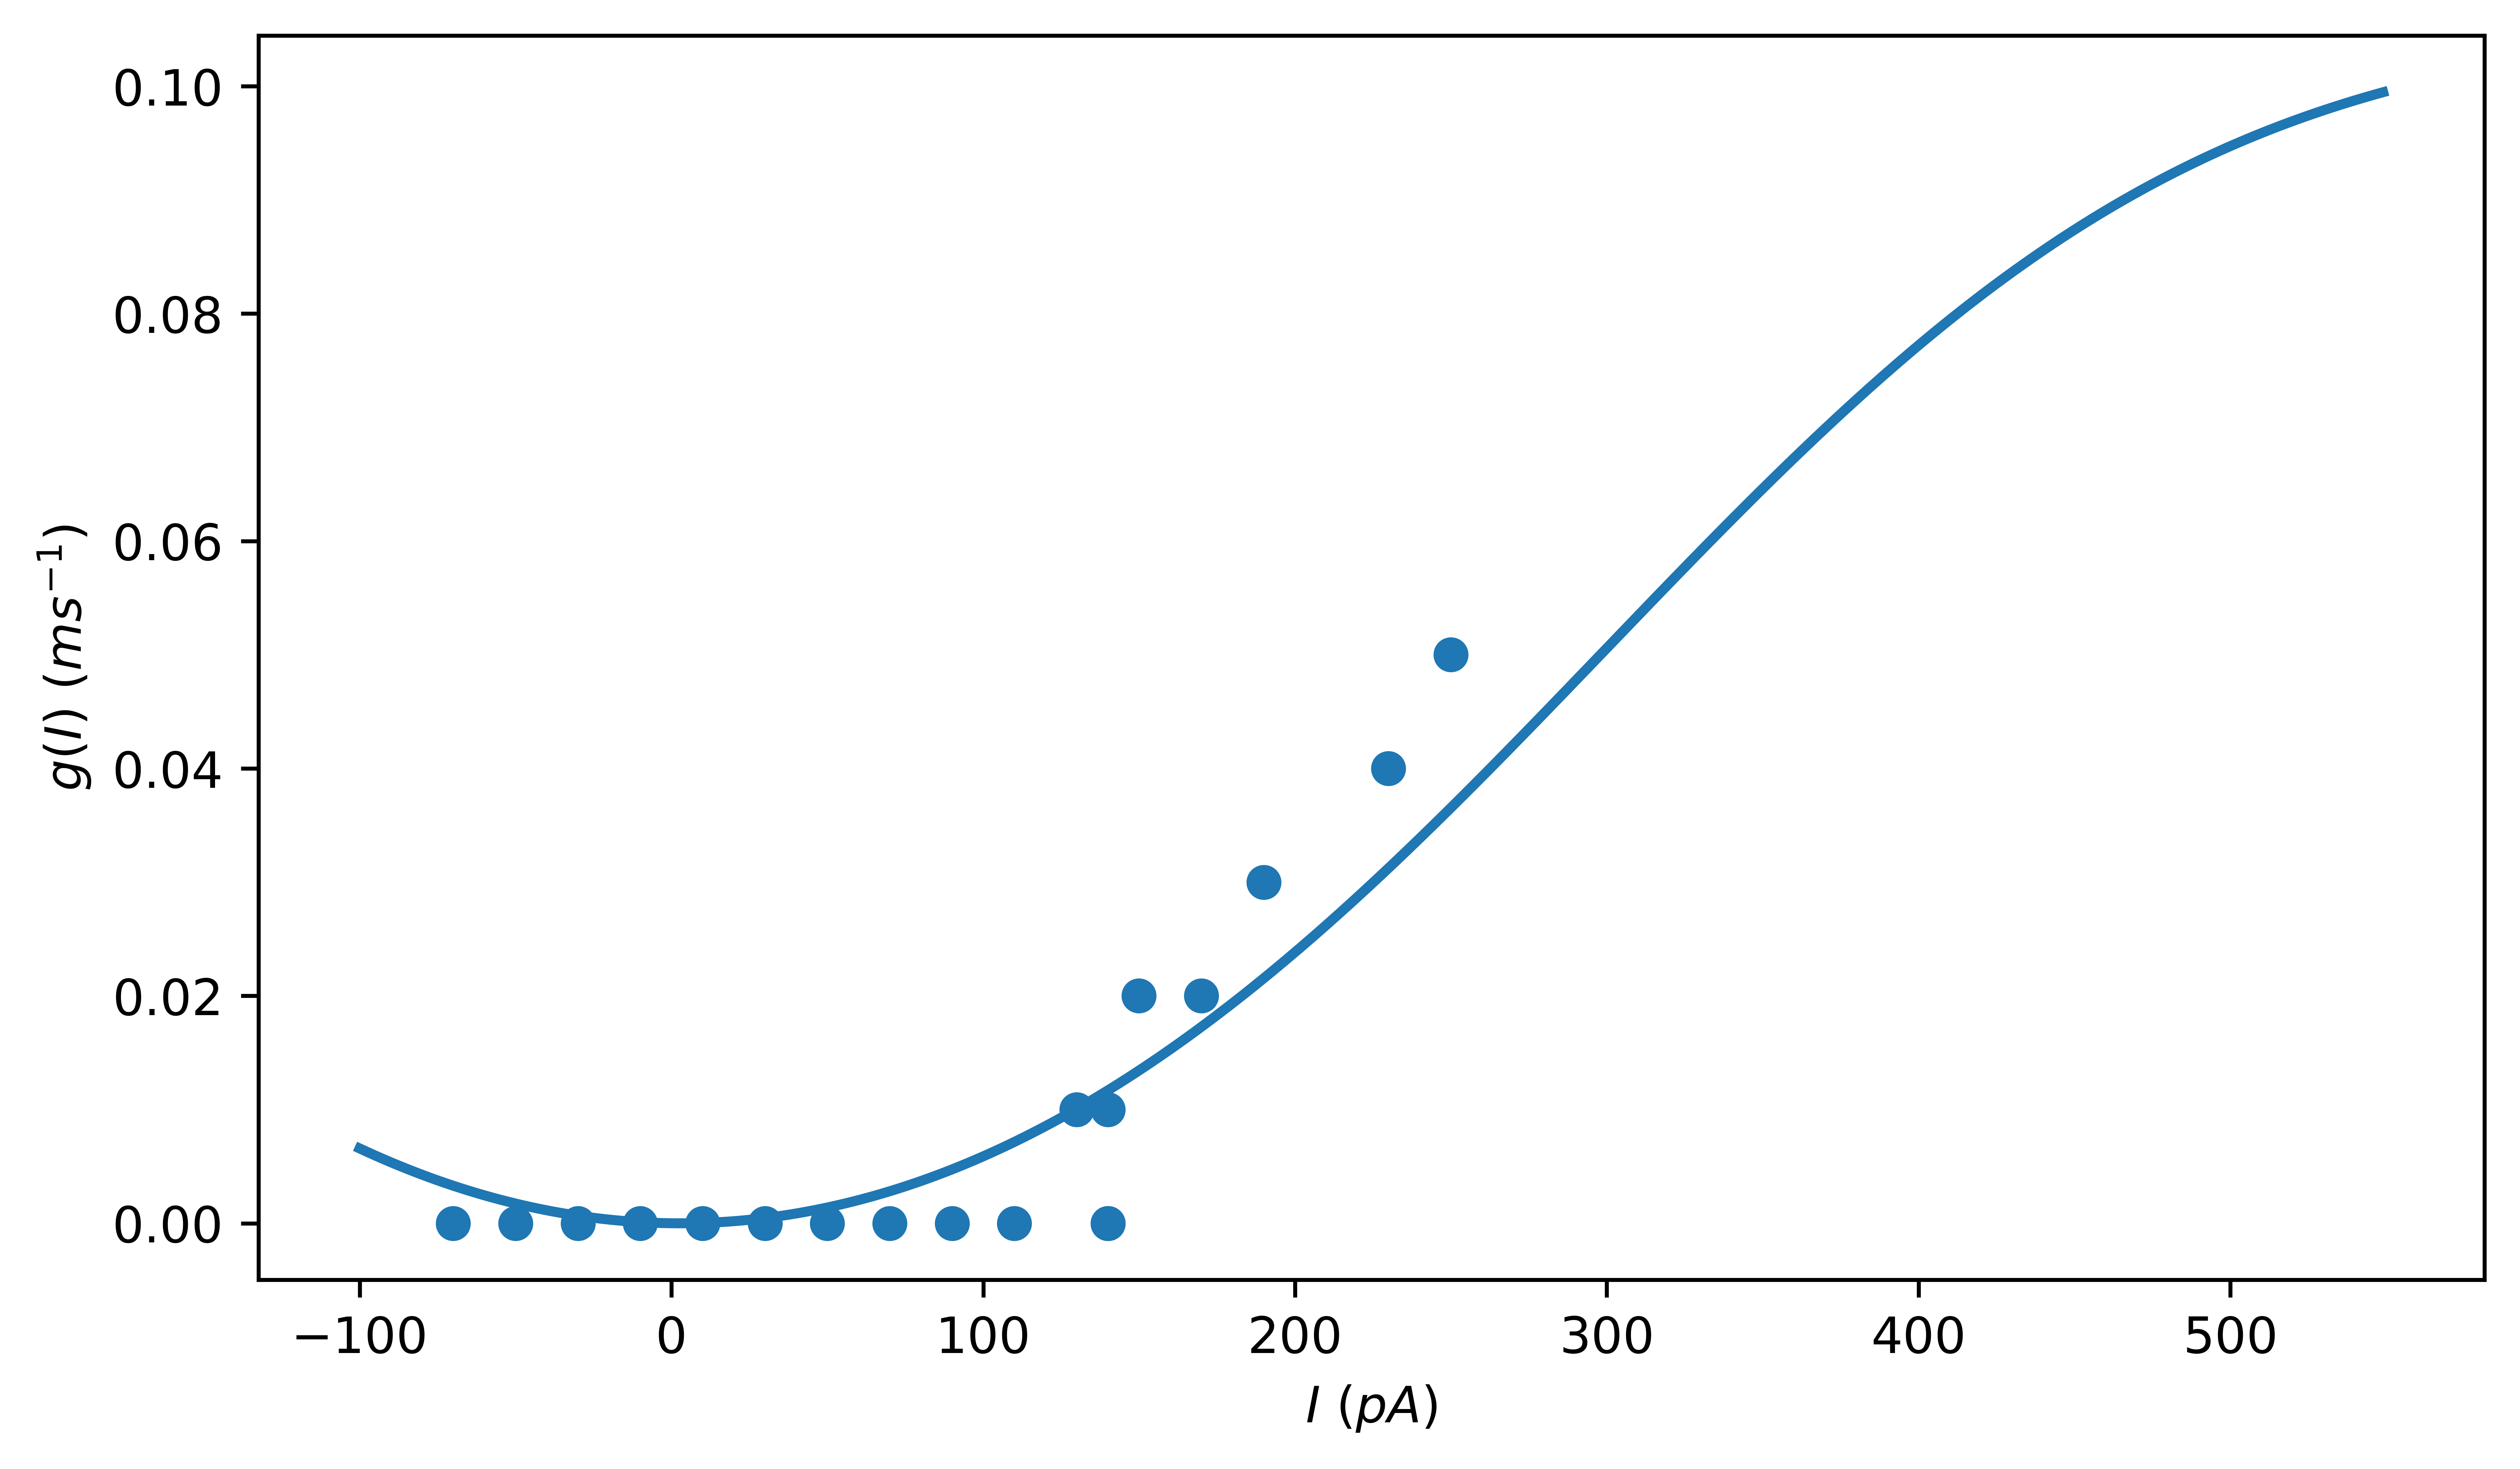

In [42]:
ids = p[(p["activation_type"] == "polynomial") & (p["activation_bin_size"] == 100)]["cell_id"].tolist()

for cell_id in ids[:10]:
    activation_bin_size = 100
    model = load_model(p, cell_id, activation_bin_size, 'polynomial')
    data = get_data(cell_id)
    Is_np, fs_np = preprocess_data(data, activation_bin_size)
    Is = torch.tensor(Is_np)
    fs = torch.tensor(fs_np)
    plot_activation(Is, fs, model)